<a href="https://colab.research.google.com/github/kingsleyyeon/DP/blob/main/ToTProtein_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# For best performance, please run everything in A100 high ram

# Fast binding score (baseline_mlp_combined_ft.pt, weights saved)

In [2]:
!pip install fair-esm torch pandas numpy scikit-learn requests biopython goatools -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import esm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import requests
import gzip
import io
from tqdm. auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pickle
import os

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:  {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 16.8 MB/s eta 0:00:00
Using device:  cuda


In [3]:
# ============================================================================
# CELL: Download and set up seq_ppi (Sun et al.) dataset
# - Clones repo
# - Verifies expected files exist
# ============================================================================

import os
import subprocess

REPO_URL = "https://github.com/muhaochen/seq_ppi.git"
REPO_DIR = "seq_ppi"

# Clone only if not already present
if not os.path.isdir(REPO_DIR):
    print("Cloning seq_ppi repository...")
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL],
        check=True
    )
else:
    print("seq_ppi already exists, skipping clone.")

# Expected file check
EXPECTED = os.path.join(REPO_DIR, "sun", "preprocessed", "Supp-AB.tsv")

print("\nChecking expected dataset file:")
if os.path.isfile(EXPECTED):
    print("✅ Found:", EXPECTED)
else:
    print("❌ Missing:", EXPECTED)
    print("\nAvailable files under seq_ppi/sun:")
    subprocess.run(["find", os.path.join(REPO_DIR, "sun"), "-maxdepth", "3", "-type", "f"])


Cloning seq_ppi repository...

Checking expected dataset file:
✅ Found: seq_ppi/sun/preprocessed/Supp-AB.tsv


In [4]:
# ============================================================================
# CELL 2 : Load Supp-AB.tsv (has a header row)
# ============================================================================

import pandas as pd

PAIR_PATH = "seq_ppi/sun/preprocessed/Supp-AB.tsv"

# read WITH header row
df = pd.read_csv(PAIR_PATH, sep="\t", header=0, dtype=str)
print("Loaded:", df.shape)
print(df.head())

# normalize column names just in case
cols = [c.lower().strip() for c in df.columns]
df.columns = cols

# expect columns like: v1, v2, label
if not (("v1" in df.columns) and ("v2" in df.columns) and ("label" in df.columns)):
    raise RuntimeError(f"Unexpected columns: {df.columns.tolist()}")

pairs_df = pd.DataFrame({
    "protein1": df["v1"].astype(str).str.strip(),
    "protein2": df["v2"].astype(str).str.strip(),
    "label":   df["label"].astype(int),
})

pairs_df = pairs_df[pairs_df["protein1"] != pairs_df["protein2"]].drop_duplicates()
pairs_df = pairs_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(pairs_df["label"].value_counts())
print("Total pairs:", len(pairs_df))
print("Unique proteins:", len(set(pairs_df["protein1"]) | set(pairs_df["protein2"])))


Loaded: (73108, 3)
               v1              v2 label
0     NP_663777.1     NP_001233.1     1
1     NP_055436.2     NP_001420.2     1
2     NP_003630.1  NP_001073594.1     1
3  NP_001001998.1     NP_067000.1     1
4     NP_001888.2     NP_001782.1     1
label
1    36629
0    36479
Name: count, dtype: int64
Total pairs: 73108
Unique proteins: 10364


In [5]:
# ============================================================================
# CELL 3: choose the correct id->sequence dictionary by coverage
# ============================================================================

import pandas as pd
import numpy as np
import glob, os, re
from tqdm.auto import tqdm

# IDs in your pairs
ids_needed = set(pairs_df["protein1"].astype(str)) | set(pairs_df["protein2"].astype(str))
print("Unique IDs needed:", len(ids_needed))

# Candidate dictionary TSVs (sun + yeast + multi species) shown in your list
dict_cands = []
dict_cands += glob.glob("seq_ppi/sun/preprocessed/*.tsv")
dict_cands += glob.glob("seq_ppi/yeast/preprocessed/*dictionary*.tsv")
dict_cands += glob.glob("seq_ppi/multi_species/preprocessed/*dictionary*.tsv")

dict_cands = sorted(set(dict_cands))
print("Dictionary candidates:", len(dict_cands))
for p in dict_cands[:20]:
    print("  ", p)

AA_RE = re.compile(r"^[ACDEFGHIKLMNPQRSTVWYBXZJUO\-]+$", re.I)

def load_id2seq_from_tsv(path):
    """
    Robust: tries to detect which column is the sequence column by AA-like content.
    Returns dict {id: seq}
    """
    df = pd.read_csv(path, sep="\t", header=None, dtype=str)
    df = df.dropna(how="all")
    if df.shape[1] < 2:
        return {}

    # Heuristic: first column is usually ID
    ids = df.iloc[:, 0].astype(str).str.strip()

    # Find best sequence column: the one with most AA-looking strings of decent length
    best_j, best_score = None, -1
    for j in range(1, df.shape[1]):
        col = df.iloc[:, j].astype(str).str.strip()
        # score sequences that look like AA and are length>=30
        ok = col.map(lambda s: (len(s) >= 30) and (AA_RE.match(s) is not None)).sum()
        if ok > best_score:
            best_score = ok
            best_j = j

    if best_j is None or best_score < 100:  # too few AA-like entries
        return {}

    seqs = df.iloc[:, best_j].astype(str).str.strip()
    d = dict(zip(ids, seqs))
    return d

def coverage_score(d):
    if not d:
        return (0, 0)
    hit = sum((x in d) for x in ids_needed)
    # also check how many sequences are AA-like and not crazy long
    sample = list(d.values())[:2000]
    aa_ok = sum((len(s) >= 30) and (AA_RE.match(s) is not None) for s in sample)
    return (hit, aa_ok)

best = None
best_path = None
best_stats = None

for p in dict_cands:
    d = load_id2seq_from_tsv(p)
    hit, aa_ok = coverage_score(d)
    print(f"{p}: hits={hit}/{len(ids_needed)} aa_ok(sample)={aa_ok}")
    if best is None or (hit, aa_ok) > best_stats:
        best, best_path, best_stats = d, p, (hit, aa_ok)

if best is None or best_stats[0] == 0:
    raise RuntimeError("No dictionary file matched your pair IDs. Need to inspect the pos/neg pair files chosen in CELL 2.")

protein_sequences = best
print("\nChosen sequence source:", best_path)
print("Coverage:", best_stats[0], "/", len(ids_needed))
print("Loaded sequences:", len(protein_sequences))

# Attach sequences
pairs_df["seq1"] = pairs_df["protein1"].map(protein_sequences)
pairs_df["seq2"] = pairs_df["protein2"].map(protein_sequences)

before = len(pairs_df)
pairs_df = pairs_df.dropna(subset=["seq1","seq2"]).reset_index(drop=True)
print("Dropped (missing seq):", before - len(pairs_df), "Remaining:", len(pairs_df))

# Sanity check: sequences should be AA-like
bad = (~pairs_df["seq1"].str.match(AA_RE)) | (~pairs_df["seq2"].str.match(AA_RE))
print("Non-AA-like pairs remaining:", bad.sum())
pairs_df = pairs_df[~bad].reset_index(drop=True)

# Length filter (make it less strict initially)
# MAX_LEN = 1500  # <- temporarily relax to diagnose
MAX_LEN = 1022
pairs_df = pairs_df[
    (pairs_df["seq1"].str.len() <= MAX_LEN) &
    (pairs_df["seq2"].str.len() <= MAX_LEN) &
    (pairs_df["seq1"].str.len() >= 30) &
    (pairs_df["seq2"].str.len() >= 30)
].reset_index(drop=True)

print("After length filter:", len(pairs_df), "pos rate:", pairs_df["label"].mean())

# Keep downstream columns expected by your existing PPIDataset
for col in ["combined_score","neighborhood","fusion","cooccurence","coexpression","experimental","database","textmining"]:
    if col not in pairs_df.columns:
        pairs_df[col] = 0


ppi_dataset = pairs_df


Unique IDs needed: 10364
Dictionary candidates: 5
   seq_ppi/multi_species/preprocessed/CeleganDrosophilaEcoli.dictionary.filtered.tsv
   seq_ppi/multi_species/preprocessed/CeleganDrosophilaEcoli.dictionary.tsv
   seq_ppi/sun/preprocessed/SEQ-Supp-ABCD.tsv
   seq_ppi/sun/preprocessed/Supp-AB.tsv
   seq_ppi/yeast/preprocessed/protein.dictionary.tsv
seq_ppi/multi_species/preprocessed/CeleganDrosophilaEcoli.dictionary.filtered.tsv: hits=1/10364 aa_ok(sample)=2000
seq_ppi/multi_species/preprocessed/CeleganDrosophilaEcoli.dictionary.tsv: hits=2/10364 aa_ok(sample)=2000
seq_ppi/sun/preprocessed/SEQ-Supp-ABCD.tsv: hits=10364/10364 aa_ok(sample)=1999
seq_ppi/sun/preprocessed/Supp-AB.tsv: hits=0/10364 aa_ok(sample)=0
seq_ppi/yeast/preprocessed/protein.dictionary.tsv: hits=0/10364 aa_ok(sample)=2000

Chosen sequence source: seq_ppi/sun/preprocessed/SEQ-Supp-ABCD.tsv
Coverage: 10364 / 10364
Loaded sequences: 10364
Dropped (missing seq): 0 Remaining: 73108
Non-AA-like pairs remaining: 0
After leng

In [13]:
# ============================================================================
# CELL 4: Generate ESM-2 embeddings (cached to CSV)
# ============================================================================

import os
import torch
import pandas as pd
import esm
from tqdm.auto import tqdm

EMB_DIR = "string_data"
os.makedirs(EMB_DIR, exist_ok=True)

CSV_PATH = os.path.join(EMB_DIR, "protein_embeddings.csv")
PT_PATH  = os.path.join(EMB_DIR, "protein_embeddings.pt")

# ------------------------------------------------------------
# If embeddings already exist, load and skip computation
# ------------------------------------------------------------
if os.path.exists(CSV_PATH):
    print("Loading cached embeddings from CSV...")
    emb_df = pd.read_csv(CSV_PATH, index_col=0)

    protein_embeddings = {
        pid: torch.tensor(emb_df.loc[pid].values, dtype=torch.float32)
        for pid in emb_df.index
    }

    print("Loaded embeddings:", len(protein_embeddings))
    print("Embedding dim:", next(iter(protein_embeddings.values())).shape[0])

else:
    # ------------------------------------------------------------
    # ESM-2 embedding generator
    # ------------------------------------------------------------
    class ESM2EmbeddingGenerator:
        def __init__(self, model_name="esm2_t12_35M_UR50D", device="cuda"):
            print(f"Loading ESM-2 model: {model_name}")
            self.model, self.alphabet = esm.pretrained.load_model_and_alphabet(model_name)
            self.model = self.model.to(device).eval()
            self.batch_converter = self.alphabet.get_batch_converter()
            self.device = device
            self.repr_layer = self.model.num_layers
            self.pad_idx = self.alphabet.padding_idx

        def generate(self, sequences, batch_size=4):
            embeddings = {}

            with torch.no_grad():
                for i in tqdm(range(0, len(sequences), batch_size),
                              desc="Generating ESM embeddings"):
                    batch = sequences[i:i + batch_size]
                    _, _, tokens = self.batch_converter(batch)
                    tokens = tokens.to(self.device)

                    out = self.model(tokens, repr_layers=[self.repr_layer])
                    reps = out["representations"][self.repr_layer]  # [B, T, d]

                    nonpad = tokens.ne(self.pad_idx)
                    nonpad[:, 0] = False  # drop CLS

                    for j, (pid, _) in enumerate(batch):
                        m = nonpad[j]
                        if m.sum() == 0:
                            emb = reps[j, 0]
                        else:
                            emb = reps[j, m].mean(dim=0)
                        embeddings[pid] = emb.float().cpu()

            return embeddings

    # ------------------------------------------------------------
    # Prepare sequences
    # ------------------------------------------------------------
    unique_proteins = sorted(
        set(ppi_dataset["protein1"]) | set(ppi_dataset["protein2"])
    )
    print("Total unique proteins:", len(unique_proteins))

    sequences_for_embedding = [
        (pid, protein_sequences[pid]) for pid in unique_proteins
    ]

    # ------------------------------------------------------------
    # Generate embeddings
    # ------------------------------------------------------------
    generator = ESM2EmbeddingGenerator(
        model_name="esm2_t12_35M_UR50D",
        device=device
    )

    protein_embeddings = generator.generate(
        sequences_for_embedding,
        batch_size=4
    )

    # ------------------------------------------------------------
    # Save as CSV + PT
    # ------------------------------------------------------------
    print("Saving embeddings to CSV + PT...")

    emb_df = pd.DataFrame.from_dict(
        {k: v.numpy() for k, v in protein_embeddings.items()},
        orient="index"
    )
    emb_df.to_csv(CSV_PATH)

    torch.save(protein_embeddings, PT_PATH)

    print("Saved:")
    print(" ", CSV_PATH)
    print(" ", PT_PATH)
    print("Embedding dim:", emb_df.shape[1])


Loading cached embeddings from CSV...
Loaded embeddings: 3857
Embedding dim: 480


In [14]:
import re

ids = list(set(ppi_dataset["protein1"]) | set(ppi_dataset["protein2"]))
n_np = sum(bool(re.match(r"^NP_\d+\.\d+$", x)) for x in ids)
n_up = sum(bool(re.match(r"^[OPQ][0-9][A-Z0-9]{3}[0-9]$|^[A-NR-Z][0-9]{5}$", x)) for x in ids)

print("unique IDs:", len(ids))
print("NP_* IDs :", n_np)
print("UniProt-like IDs:", n_up)

print("Examples NP:", [x for x in ids if x.startswith("NP_")][:10])
print("Examples UP:", [x for x in ids if not x.startswith("NP_")][:10])


unique IDs: 7650
NP_* IDs : 7650
UniProt-like IDs: 0
Examples NP: ['NP_000934.1', 'NP_002618.1', 'NP_659451.1', 'NP_443073.1', 'NP_004498.1', 'NP_060037.2', 'NP_919246.1', 'NP_065574.2', 'NP_061828.1', 'NP_620167.1']
Examples UP: []


In [ ]:
# ============================================================================
# CELL 5: Dataset + Split + DataLoaders (Pan/PIPR-style)
# - Works with: ppi_dataset DataFrame having columns: protein1, protein2, label
# - Works with: protein_embeddings dict {protein_id: torch.FloatTensor[d]}
# - Uses: random stratified split (benchmark-style)
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class PPIDataset(Dataset):
    def __init__(self, dataframe, embeddings_dict):
        self.data = dataframe.reset_index(drop=True)
        self.emb = embeddings_dict

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        p1 = row["protein1"]
        p2 = row["protein2"]
        return {
            "emb1": self.emb[p1],
            "emb2": self.emb[p2],
            "label": torch.tensor(float(row["label"]), dtype=torch.float32),
        }

# -------------------------
# Split (benchmark-style)
# -------------------------
train_df, temp_df = train_test_split(
    ppi_dataset,
    test_size=0.30,
    random_state=42,
    stratify=ppi_dataset["label"]
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("\nDataset splits:")
print(f"  Train: {len(train_df)} samples | pos rate={train_df['label'].mean():.3f}")
print(f"  Val  : {len(val_df)} samples | pos rate={val_df['label'].mean():.3f}")
print(f"  Test : {len(test_df)} samples | pos rate={test_df['label'].mean():.3f}")

# -------------------------
# Datasets + Loaders
# -------------------------
train_dataset = PPIDataset(train_df, protein_embeddings)
val_dataset   = PPIDataset(val_df, protein_embeddings)
test_dataset  = PPIDataset(test_df, protein_embeddings)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nDataLoaders created with batch_size={batch_size}")



Dataset splits:
  Train: 39434 samples | pos rate=0.469
  Val  : 8450 samples | pos rate=0.469
  Test : 8451 samples | pos rate=0.469

DataLoaders created with batch_size=64


In [21]:
import torch
import torch.nn as nn

class BaselineMLP(nn.Module):
    """Baseline: concat + MLP (fine)"""
    def __init__(self, embedding_dim, hidden_dims=(512,256,128), dropout=0.3):
        super().__init__()
        layers = []
        d = 2 * embedding_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout), nn.BatchNorm1d(h)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, emb1, emb2):
        x = torch.cat([emb1, emb2], dim=1)
        return torch.sigmoid(self.net(x).squeeze(-1))


class PairFeatureMLP(nn.Module):
    """Stronger for pooled embeddings: [e1, e2, |e1-e2|, e1*e2] + MLP"""
    def __init__(self, embedding_dim, hidden_dims=(512,256,128), dropout=0.3):
        super().__init__()
        layers = []
        d = 4 * embedding_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout), nn.BatchNorm1d(h)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, emb1, emb2):
        x = torch.cat([emb1, emb2, (emb1 - emb2).abs(), emb1 * emb2], dim=1)
        return torch.sigmoid(self.net(x).squeeze(-1))


# If (and only if) you later switch to per-residue embeddings, this becomes meaningful
class CrossAttentionPPI(nn.Module):
    """Cross-attn only meaningful with per-residue embeddings (seq_len > 1)."""
    def __init__(self, embedding_dim, num_heads=8, hidden_dims=(512,256,128), dropout=0.3):
        super().__init__()
        self.attn_1to2 = nn.MultiheadAttention(embedding_dim, num_heads, dropout=dropout, batch_first=True)
        self.attn_2to1 = nn.MultiheadAttention(embedding_dim, num_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(embedding_dim)
        self.ln2 = nn.LayerNorm(embedding_dim)

        layers = []
        d = 4 * embedding_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout), nn.BatchNorm1d(h)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.cls = nn.Sequential(*layers)

    def forward(self, emb1, emb2):
        # emb1/emb2 expected shape [B, L, D] for real cross-attn
        a1, _ = self.attn_1to2(emb1, emb2, emb2)
        a2, _ = self.attn_2to1(emb2, emb1, emb1)

        # pool after attn
        e1 = emb1.mean(dim=1)
        e2 = emb2.mean(dim=1)
        a1p = self.ln1(a1 + emb1).mean(dim=1)
        a2p = self.ln2(a2 + emb2).mean(dim=1)

        x = torch.cat([e1, e2, a1p, a2p], dim=1)
        return torch.sigmoid(self.cls(x).squeeze(-1))


embedding_dim = next(iter(protein_embeddings.values())).shape[0]
print("Embedding dim:", embedding_dim)

baseline_model = BaselineMLP(embedding_dim).to(device)
pairfeat_model = PairFeatureMLP(embedding_dim).to(device)

print("Baseline MLP params:", sum(p.numel() for p in baseline_model.parameters()))
print("PairFeature MLP params:", sum(p.numel() for p in pairfeat_model.parameters()))


Embedding dim: 480
Baseline MLP params: 658177
PairFeature MLP params: 1149697


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(dataloader, desc="Training", leave=False):
        emb1 = batch["emb1"].to(device)
        emb2 = batch["emb2"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        preds = model(emb1, emb2)              # preds in [0,1], shape [B]
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(dataloader))
    auc = roc_auc_score(all_labels, all_preds)
    ap = average_precision_score(all_labels, all_preds)
    return avg_loss, auc, ap


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        emb1 = batch["emb1"].to(device)
        emb2 = batch["emb2"].to(device)
        labels = batch["label"].to(device)

        preds = model(emb1, emb2)
        loss = criterion(preds, labels)

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(dataloader))
    auc = roc_auc_score(all_labels, all_preds)
    ap = average_precision_score(all_labels, all_preds)
    return avg_loss, auc, ap, all_preds, all_labels


def train_model(model, train_loader, val_loader, device,
                num_epochs=20, lr=1e-4, model_name="model"):
    criterion = nn.BCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_val_auc = -1.0
    history = dict(train_loss=[], train_auc=[], train_ap=[],
                   val_loss=[], val_auc=[], val_ap=[])

    print("\n" + "="*80)
    print(f"Training {model_name}")
    print("="*80 + "\n")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        train_loss, train_auc, train_ap = train_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_auc, val_ap, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_auc)

        history["train_loss"].append(train_loss)
        history["train_auc"].append(train_auc)
        history["train_ap"].append(train_ap)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["val_ap"].append(val_ap)

        print(f"  Train Loss: {train_loss:.4f} | AUC: {train_auc:.4f} | AP: {train_ap:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | AP: {val_ap:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            os.makedirs("string_data", exist_ok=True)
            torch.save(model.state_dict(), f"string_data/{model_name}_best.pt")
            print(f"  ✓ New best model saved! (AUC: {best_val_auc:.4f})")

        print()

    print(f"Training completed! Best validation AUC: {best_val_auc:.4f}\n")
    return history


In [ ]:
# ============================================================================
# CELL: Train models (adapted to our train_model signature)
# ============================================================================

# Baseline MLP
baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=15,
    lr=1e-4,
    model_name="baseline_mlp"
)


# Multi-task model:
# DO NOT run this unless you have real evidence labels in the dataset and your PPIDataset returns evidence_labels.
# Right now, evidence is either missing or all zeros, so multitask training is meaningless/harmful.
# multitask_history = train_model(
#     model=multitask_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     num_epochs=15,
#     lr=1e-4,
#     model_name="multitask_ppi"
# )



Training baseline_mlp

Epoch 1/15


Training:   0%|          | 0/617 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/133 [00:00<?, ?it/s]

  Train Loss: 0.4027 | AUC: 0.8979 | AP: 0.8888
  Val   Loss: 0.2828 | AUC: 0.9572 | AP: 0.9526
  ✓ New best model saved! (AUC: 0.9572)

Epoch 2/15


Training:   0%|          | 0/617 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7849a817e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7849a817e480>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Train Loss: 0.1416 | AUC: 0.9868 | AP: 0.9847
  Val   Loss: 0.1266 | AUC: 0.9896 | AP: 0.9881
  ✓ New best model saved! (AUC: 0.9896)

Epoch 15/15


Training:   0%|          | 0/617 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/133 [00:00<?, ?it/s]

  Train Loss: 0.1332 | AUC: 0.9882 | AP: 0.9865
  Val   Loss: 0.1187 | AUC: 0.9900 | AP: 0.9889
  ✓ New best model saved! (AUC: 0.9900)

Training completed! Best validation AUC: 0.9900



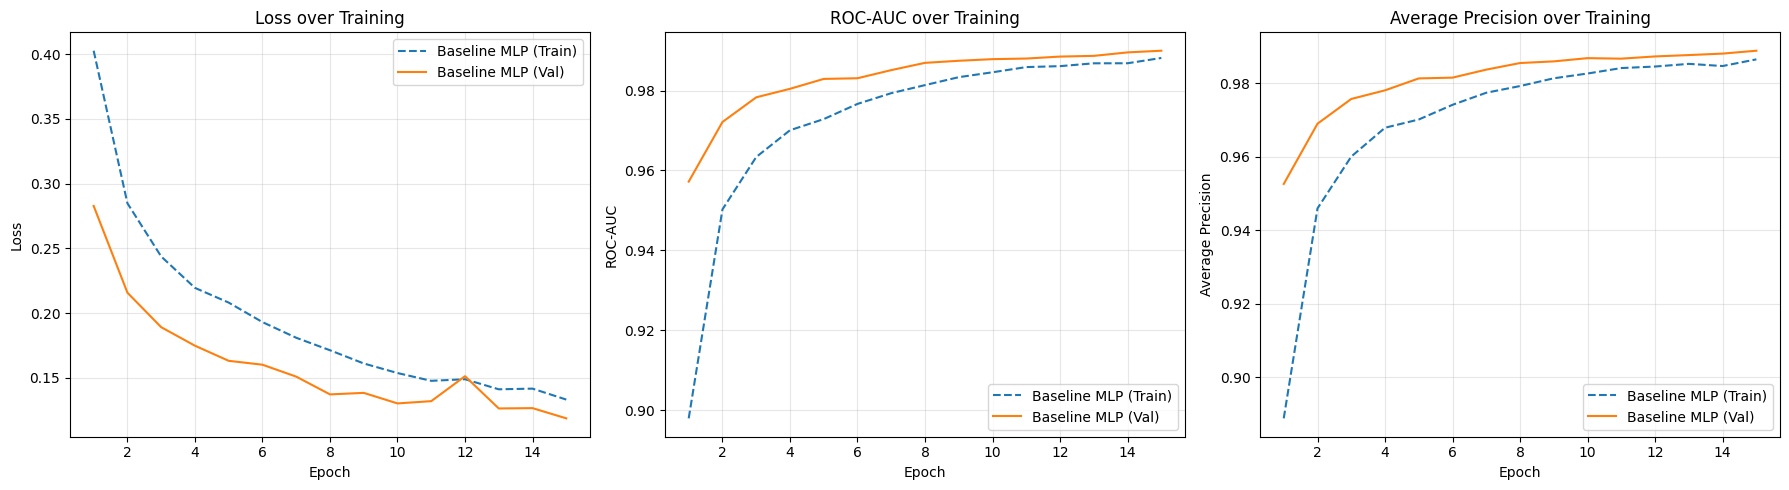

In [ ]:
# ============================================================================
# CELL: Plot training history (Baseline only; no cross-attn / no multitask)
# ============================================================================

import os
import matplotlib.pyplot as plt

os.makedirs("string_data", exist_ok=True)

def plot_training_history(histories, model_names, out_path="string_data/training_history.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = ["loss", "auc", "ap"]
    titles  = ["Loss", "ROC-AUC", "Average Precision"]

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx]
        for history, name in zip(histories, model_names):
            epochs = range(1, len(history[f"train_{metric}"]) + 1)
            ax.plot(epochs, history[f"train_{metric}"], "--", label=f"{name} (Train)")
            ax.plot(epochs, history[f"val_{metric}"], "-",  label=f"{name} (Val)")

        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.set_title(f"{title} over Training")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# Plot (adapted: Baseline only)
plot_training_history(
    histories=[baseline_history],
    model_names=["Baseline MLP"]
)


In [23]:
# ============================================================================
# CELL: Test set evaluation (Baseline only)
# ============================================================================

import torch
import numpy as np
from sklearn.metrics import classification_report
import torch.nn as nn

def evaluate_test_set(model, test_loader, device, model_name):
    print("\n" + "="*80)
    print(f"Testing {model_name}")
    print("="*80 + "\n")

    criterion = nn.BCELoss()

    test_loss, test_auc, test_ap, preds, labels = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=device
    )

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test ROC-AUC: {test_auc:.4f}")
    print(f"Test Average Precision: {test_ap:.4f}")

    # Binary predictions at 0.5
    preds_binary = (np.array(preds) > 0.5).astype(int)

    print("\nClassification Report:")
    print(
        classification_report(
            labels,
            preds_binary,
            target_names=["Non-Interaction", "Interaction"]
        )
    )

    return {
        "loss": test_loss,
        "auc": test_auc,
        "ap": test_ap,
        "preds": preds,
        "labels": labels
    }


# ------------------------------------------------------------------
# Load best baseline model
# ------------------------------------------------------------------
baseline_model.load_state_dict(
    torch.load("string_data/baseline_mlp_best.pt", map_location=device)
)
baseline_model.to(device)

# ------------------------------------------------------------------
# Evaluate on test set
# ------------------------------------------------------------------
baseline_results = evaluate_test_set(
    model=baseline_model,
    test_loader=test_loader,
    device=device,
    model_name="Baseline MLP"
)


NameError: name 'test_loader' is not defined

In [24]:
# ============================================================================
# CELL: ROC & Precision–Recall curves (Baseline only)
# ============================================================================

import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

os.makedirs("string_data", exist_ok=True)

def plot_roc_pr_curves(results_dict, out_path="string_data/roc_pr_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --------------------
    # ROC Curve
    # --------------------
    ax = axes[0]
    for name, results in results_dict.items():
        fpr, tpr, _ = roc_curve(results["labels"], results["preds"])
        ax.plot(
            fpr, tpr,
            linewidth=2,
            label=f"{name} (AUC = {results['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --------------------
    # Precision–Recall Curve
    # --------------------
    ax = axes[1]
    for name, results in results_dict.items():
        precision, recall, _ = precision_recall_curve(
            results["labels"], results["preds"]
        )
        ax.plot(
            recall, precision,
            linewidth=2,
            label=f"{name} (AP = {results['ap']:.3f})"
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall Curve")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------------
# Plot (Baseline only)
# ------------------------------------------------------------------
plot_roc_pr_curves(
    results_dict={
        "Baseline MLP": baseline_results
    }
)


NameError: name 'baseline_results' is not defined

In [25]:
# ============================================================================
# CELL: Single-pair prediction + examples (Baseline only)
# ============================================================================

import numpy as np

def predict_interaction(model, protein_id1, protein_id2, embeddings_dict, device):
    """
    Predict interaction probability for a protein pair (baseline-style models).

    Returns: {"interaction_probability": float}
    """
    model.eval()
    with torch.no_grad():
        emb1 = embeddings_dict[protein_id1].unsqueeze(0).to(device)  # [1, d]
        emb2 = embeddings_dict[protein_id2].unsqueeze(0).to(device)  # [1, d]
        prob = model(emb1, emb2).item()
    return {"interaction_probability": prob}


print("\n" + "="*80)
print("EXAMPLE PREDICTIONS (Baseline MLP)")
print("="*80)

# sample a few from test set
example_pairs = test_df.sample(5, random_state=42)

for _, row in example_pairs.iterrows():
    p1, p2 = row["protein1"], row["protein2"]
    true_label = int(row["label"])

    pred = predict_interaction(baseline_model, p1, p2, protein_embeddings, device)
    prob = pred["interaction_probability"]

    print(f"\nProtein Pair: {p1} <-> {p2}")
    print(f"True Label: {'Interaction' if true_label == 1 else 'No Interaction'}")
    print(f"Predicted Probability: {prob:.4f}")
    print(f"Prediction: {'Interaction' if prob > 0.5 else 'No Interaction'}")

print("\n" + "="*80)



EXAMPLE PREDICTIONS (Baseline MLP)


NameError: name 'test_df' is not defined

## Query prediction

In [22]:
# ============================================================================
# CELL: FASTA conversion + predict interaction from raw sequences (Baseline)
# - Uses your trained baseline_model + ESM2EmbeddingGenerator logic
# - Writes a FASTA file for the two sequences
# - Computes ESM embeddings on-the-fly (no UniProt IDs needed)
# ============================================================================

import os
import torch
import esm
from textwrap import wrap

# -------------------------
# Inputs
# -------------------------
seq1 = "GHHHHHHEFDQVQYENTLKNFKIREQQFDNSWAAGFSMAALLNATKNTDTYNAHDIMRTLYPEVSEQDLPNCATFPNQMIEYGKSQGRDIHYQEGVPSYNQVDQLTKDNVGIMILAQSVSQNPNDPHLGHALAVVGNAKINDQEKLIYWNPWDTELSIQDADSSLLHLSFNRDYNWYGSMIGY"
seq2 = "GSMYQLQFINLVYDTTKLTHLEQTNINLFIGNWSNHQLQKSICIRHGDDTSHNQYHILFIDTAHQRIKFSSFDNEEIIYILDYDDTQHILMQTSSKQGIGTSRPIVYERLV"

id1 = "query_protein_1"
id2 = "query_protein_2"

OUT_DIR = "string_data"
os.makedirs(OUT_DIR, exist_ok=True)
FASTA_PATH = os.path.join(OUT_DIR, "query_pair.fasta")

# -------------------------
# Write FASTA (two entries)
# -------------------------
def write_fasta(path, records, width=80):
    with open(path, "w") as f:
        for pid, s in records:
            f.write(f">{pid}\n")
            f.write("\n".join(wrap(s, width=width)) + "\n")

write_fasta(FASTA_PATH, [(id1, seq1), (id2, seq2)])
print("Wrote FASTA:", FASTA_PATH)

# -------------------------
# ESM embedding (mean pool)
# -------------------------
class ESM2EmbeddingGenerator:
    def __init__(self, model_name="esm2_t12_35M_UR50D", device="cuda"):
        print(f"Loading ESM-2 model: {model_name}")
        self.model, self.alphabet = esm.pretrained.load_model_and_alphabet(model_name)
        self.model = self.model.to(device).eval()
        self.batch_converter = self.alphabet.get_batch_converter()
        self.device = device
        self.repr_layer = self.model.num_layers
        self.pad_idx = self.alphabet.padding_idx

    @torch.no_grad()
    def embed_pair(self, pid_seq_pairs):
        # pid_seq_pairs: list of (id, seq)
        _, _, toks = self.batch_converter(pid_seq_pairs)
        toks = toks.to(self.device)

        out = self.model(toks, repr_layers=[self.repr_layer], return_contacts=False)
        reps = out["representations"][self.repr_layer]  # [B, T, d]

        nonpad = toks.ne(self.pad_idx)
        nonpad[:, 0] = False  # drop CLS

        embs = {}
        for j, (pid, _) in enumerate(pid_seq_pairs):
            m = nonpad[j]
            if m.sum().item() == 0:
                emb = reps[j, 0]
            else:
                emb = reps[j, m].mean(dim=0)
            embs[pid] = emb.float().cpu()
        return embs

# -------------------------
# Predict
# -------------------------
# Ensure baseline_model is loaded (best checkpoint) before running this cell:
# baseline_model.load_state_dict(torch.load("string_data/baseline_mlp_best.pt", map_location=device))
baseline_model.eval()

generator = ESM2EmbeddingGenerator(model_name="esm2_t12_35M_UR50D", device=device)
query_embs = generator.embed_pair([(id1, seq1), (id2, seq2)])

emb1 = query_embs[id1].unsqueeze(0).to(device)  # [1, d]
emb2 = query_embs[id2].unsqueeze(0).to(device)

with torch.no_grad():
    prob = baseline_model(emb1, emb2).item()

print("\n" + "="*80)
print("QUERY PREDICTION (Baseline MLP)")
print("="*80)
print(f"Protein 1 length: {len(seq1)}")
print(f"Protein 2 length: {len(seq2)}")
print(f"Predicted interaction probability: {prob:.4f}")
print(f"Prediction: {'Interaction' if prob > 0.5 else 'No Interaction'}")
print("="*80)


Wrote FASTA: string_data/query_pair.fasta
Loading ESM-2 model: esm2_t12_35M_UR50D

QUERY PREDICTION (Baseline MLP)
Protein 1 length: 183
Protein 2 length: 111
Predicted interaction probability: 0.0108
Prediction: No Interaction


##External data set validation

In [15]:
# ============================================================================
# CELL: Load cached protein embeddings into memory
# ============================================================================

import os
import torch

EMB_PT = "string_data/protein_embeddings.pt"

if not os.path.exists(EMB_PT):
    raise RuntimeError(f"Embedding file not found: {EMB_PT}")

protein_embeddings = torch.load(EMB_PT, map_location="cpu")

print("Loaded protein_embeddings from:", EMB_PT)
print("Number of proteins:", len(protein_embeddings))

# sanity check
k = next(iter(protein_embeddings))
print("Example ID:", k)
print("Embedding shape:", protein_embeddings[k].shape)


Loaded protein_embeddings from: string_data/protein_embeddings.pt
Number of proteins: 8676
Example ID: A0AVK6
Embedding shape: torch.Size([480])


In [16]:
# ============================================================================
# CELL 0 (NEW): Restore state from disk + build uniprot_ids_all (NP_* -> UniProtKB)
# - Loads protein_embeddings from string_data/protein_embeddings.pt (or CSV fallback)
# - Builds np_to_uniprot and uniprot_ids_all via UniProt ID mapping API
# - Saves mapping cache to string_data/np_to_uniprot.json and uniprot_ids_all.json
# ============================================================================

import os, json, time
import torch
import requests
from tqdm.auto import tqdm

os.makedirs("string_data", exist_ok=True)

# -------------------------
# 0A) Load embeddings into memory
# -------------------------
EMB_PT  = "string_data/protein_embeddings.pt"
EMB_CSV = "string_data/protein_embeddings.csv"

if os.path.exists(EMB_PT):
    protein_embeddings = torch.load(EMB_PT, map_location="cpu")
    print("Loaded embeddings from:", EMB_PT)
elif os.path.exists(EMB_CSV):
    import pandas as pd
    df = pd.read_csv(EMB_CSV, index_col=0)
    protein_embeddings = {pid: torch.tensor(row.values, dtype=torch.float32) for pid, row in df.iterrows()}
    print("Loaded embeddings from:", EMB_CSV)
else:
    raise RuntimeError("No embeddings found. Expected string_data/protein_embeddings.pt or .csv")

emb_ids = sorted(list(protein_embeddings.keys()))
print("Embeddings available:", len(emb_ids))
print("Example ID:", emb_ids[0], "| dim:", protein_embeddings[emb_ids[0]].shape[0])

# -------------------------
# 0B) UniProt ID mapping: RefSeq_Protein (NP_*) -> UniProtKB
# -------------------------
IDMAP_SUBMIT = "https://rest.uniprot.org/idmapping/run"
IDMAP_STATUS = "https://rest.uniprot.org/idmapping/status/"
IDMAP_STREAM = "https://rest.uniprot.org/idmapping/stream/"

def idmap_submit(from_db, to_db, ids):
    r = requests.post(
        IDMAP_SUBMIT,
        data={"from": from_db, "to": to_db, "ids": ",".join(ids)},
        timeout=180
    )
    r.raise_for_status()
    return r.json()["jobId"]

def idmap_wait(job_id, poll=2.0):
    with tqdm(total=1, desc="UniProt ID mapping job") as pbar:
        while True:
            r = requests.get(IDMAP_STATUS + job_id, timeout=60)
            r.raise_for_status()
            j = r.json()
            st = j.get("jobStatus")
            if st in ("NEW", "RUNNING"):
                pbar.set_postfix_str(st)
                time.sleep(poll)
                continue
            pbar.set_postfix_str(st if st else "DONE")
            pbar.update(1)
            return j

def idmap_fetch(job_id):
    r = requests.get(IDMAP_STREAM + job_id, params={"format": "json"}, timeout=300)
    r.raise_for_status()
    return r.json()

print("\nMapping NP_* -> UniProtKB (this can take a bit)...")
job_id = idmap_submit("RefSeq_Protein", "UniProtKB", emb_ids)
idmap_wait(job_id)
res = idmap_fetch(job_id)

np_to_uniprot = {}
for it in res.get("results", []):
    fr = str(it.get("from"))
    to = str(it.get("to"))
    if fr and to:
        np_to_uniprot.setdefault(fr, []).append(to)

uniprot_ids_all = sorted({u for ups in np_to_uniprot.values() for u in ups})

print("Mapped NP IDs:", len(np_to_uniprot), "/", len(emb_ids))
print("Unique UniProtKB IDs:", len(uniprot_ids_all))
print("Example UniProt IDs:", uniprot_ids_all[:10])

# -------------------------
# 0C) Save caches to disk (so you can restore without re-running mapping)
# -------------------------
with open("string_data/np_to_uniprot.json", "w") as f:
    json.dump(np_to_uniprot, f)

with open("string_data/uniprot_ids_all.json", "w") as f:
    json.dump(uniprot_ids_all, f)

print("\nSaved:")
print("  string_data/np_to_uniprot.json")
print("  string_data/uniprot_ids_all.json")


Loaded embeddings from: string_data/protein_embeddings.pt
Embeddings available: 8676
Example ID: A0AVK6 | dim: 480

Mapping NP_* -> UniProtKB (this can take a bit)...


UniProt ID mapping job:   0%|          | 0/1 [00:00<?, ?it/s]

Mapped NP IDs: 6501 / 8676
Unique UniProtKB IDs: 8380
Example UniProt IDs: ['A0A023T787', 'A0A024QYR8', 'A0A024QYX0', 'A0A024QZ64', 'A0A024QZC1', 'A0A024QZI2', 'A0A024QZK5', 'A0A024QZT4', 'A0A024R0C8', 'A0A024R0H7']

Saved:
  string_data/np_to_uniprot.json
  string_data/uniprot_ids_all.json


In [17]:
# ============================================================================
# CELL A: Build & cache UniProt accession -> gene symbol mapping (resumable)
# - Uses UniProtKB search with safe chunking
# - Caches to: string_data/uniprot_to_gene.json
# - Resumes if interrupted
# ============================================================================

import os, json, time
import requests
from tqdm.auto import tqdm

CACHE_PATH = "string_data/uniprot_to_gene.json"
os.makedirs("string_data", exist_ok=True)

# uniprot_ids_all should exist from your NP->UniProt mapping step
if "uniprot_ids_all" not in globals() or len(uniprot_ids_all) == 0:
    raise RuntimeError("uniprot_ids_all not found. Run the NP_* -> UniProt mapping step first.")

# Load cache if exists
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r") as f:
        uniprot_to_gene = json.load(f)
    print("Loaded cache:", CACHE_PATH, "| entries:", len(uniprot_to_gene))
else:
    uniprot_to_gene = {}
    print("No cache found. Creating new mapping.")

# Filter remaining IDs
remaining = [u for u in uniprot_ids_all if u not in uniprot_to_gene]
print("Total UniProt IDs:", len(uniprot_ids_all))
print("Remaining to fetch:", len(remaining))

# Tunables (safe)
CHUNK = 20        # small is safest; you can try 30/40 later
RETRIES = 3

base = "https://rest.uniprot.org/uniprotkb/search"

def fetch_chunk(batch):
    q = " OR ".join([f"accession:{x}" for x in batch])
    params = {
        "query": q,
        "format": "tsv",
        "fields": "accession,gene_names",
        "size": len(batch),
    }
    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    out = {}
    lines = r.text.strip().splitlines()
    if len(lines) <= 1:
        return out
    for ln in lines[1:]:
        parts = ln.split("\t")
        if len(parts) >= 2:
            acc = parts[0].strip()
            genes = parts[1].strip()
            if acc and genes:
                out[acc] = genes.split()[0]
    return out

# Main loop with progress bar + periodic checkpoint saves
pbar = tqdm(range(0, len(remaining), CHUNK), desc="Building UniProt→Gene map", unit="chunk")
for i in pbar:
    batch = remaining[i:i+CHUNK]

    last_err = None
    for t in range(RETRIES):
        try:
            got = fetch_chunk(batch)
            uniprot_to_gene.update(got)
            last_err = None
            break
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (t + 1))

    if last_err is not None:
        # Don’t crash; skip this batch and continue
        pbar.set_postfix_str(f"warn: {type(last_err).__name__}")
        continue

    # Save every ~50 chunks
    if (i // CHUNK) % 50 == 0:
        with open(CACHE_PATH, "w") as f:
            json.dump(uniprot_to_gene, f)
        pbar.set_postfix_str(f"saved={len(uniprot_to_gene)}")

# Final save
with open(CACHE_PATH, "w") as f:
    json.dump(uniprot_to_gene, f)

print("Done. Cached entries:", len(uniprot_to_gene))
print("Cache saved to:", CACHE_PATH)


Loaded cache: string_data/uniprot_to_gene.json | entries: 7802
Total UniProt IDs: 8380
Remaining to fetch: 578


Building UniProt→Gene map:   0%|          | 0/29 [00:00<?, ?chunk/s]

Done. Cached entries: 7802
Cache saved to: string_data/uniprot_to_gene.json


In [18]:
# ============================================================================
# CELL A: Build & cache UniProt accession -> gene symbol mapping (resumable)
# - Uses UniProtKB search with safe chunking
# - Caches to: string_data/uniprot_to_gene.json
# - Resumes if interrupted
# ============================================================================

import os, json, time
import requests
from tqdm.auto import tqdm

CACHE_PATH = "string_data/uniprot_to_gene.json"
os.makedirs("string_data", exist_ok=True)

# uniprot_ids_all should exist from your NP->UniProt mapping step
if "uniprot_ids_all" not in globals() or len(uniprot_ids_all) == 0:
    raise RuntimeError("uniprot_ids_all not found. Run the NP_* -> UniProt mapping step first.")

# Load cache if exists
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r") as f:
        uniprot_to_gene = json.load(f)
    print("Loaded cache:", CACHE_PATH, "| entries:", len(uniprot_to_gene))
else:
    uniprot_to_gene = {}
    print("No cache found. Creating new mapping.")

# Filter remaining IDs
remaining = [u for u in uniprot_ids_all if u not in uniprot_to_gene]
print("Total UniProt IDs:", len(uniprot_ids_all))
print("Remaining to fetch:", len(remaining))

# Tunables (safe)
CHUNK = 20        # small is safest; you can try 30/40 later
RETRIES = 3

base = "https://rest.uniprot.org/uniprotkb/search"

def fetch_chunk(batch):
    q = " OR ".join([f"accession:{x}" for x in batch])
    params = {
        "query": q,
        "format": "tsv",
        "fields": "accession,gene_names",
        "size": len(batch),
    }
    r = requests.get(base, params=params, timeout=60)
    r.raise_for_status()
    out = {}
    lines = r.text.strip().splitlines()
    if len(lines) <= 1:
        return out
    for ln in lines[1:]:
        parts = ln.split("\t")
        if len(parts) >= 2:
            acc = parts[0].strip()
            genes = parts[1].strip()
            if acc and genes:
                out[acc] = genes.split()[0]
    return out

# Main loop with progress bar + periodic checkpoint saves
pbar = tqdm(range(0, len(remaining), CHUNK), desc="Building UniProt→Gene map", unit="chunk")
for i in pbar:
    batch = remaining[i:i+CHUNK]

    last_err = None
    for t in range(RETRIES):
        try:
            got = fetch_chunk(batch)
            uniprot_to_gene.update(got)
            last_err = None
            break
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (t + 1))

    if last_err is not None:
        # Don’t crash; skip this batch and continue
        pbar.set_postfix_str(f"warn: {type(last_err).__name__}")
        continue

    # Save every ~50 chunks
    if (i // CHUNK) % 50 == 0:
        with open(CACHE_PATH, "w") as f:
            json.dump(uniprot_to_gene, f)
        pbar.set_postfix_str(f"saved={len(uniprot_to_gene)}")

# Final save
with open(CACHE_PATH, "w") as f:
    json.dump(uniprot_to_gene, f)

print("Done. Cached entries:", len(uniprot_to_gene))
print("Cache saved to:", CACHE_PATH)


Loaded cache: string_data/uniprot_to_gene.json | entries: 7802
Total UniProt IDs: 8380
Remaining to fetch: 578


Building UniProt→Gene map:   0%|          | 0/29 [00:00<?, ?chunk/s]

Done. Cached entries: 7802
Cache saved to: string_data/uniprot_to_gene.json


In [26]:
# ============================================================================
# CELL B (FIXED): External validation on HPRD using cached UniProt→Gene mapping
# - Auto-downloads PathwayCommons12.hprd.hgnc.txt if missing
# - Uses cached UniProt→Gene: string_data/uniprot_to_gene.json
# - Uses NP->UniProt mapping: np_to_uniprot (in memory OR loads string_data/np_to_uniprot.json)
# - Scores using baseline_mlp_best.pt (or swap to fine-tuned ckpt if you want)
# ============================================================================

import os, json, time, gzip, subprocess
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# Paths / config
# -------------------------
PC_FILE    = "PathwayCommons12.hprd.hgnc.txt"
CACHE_PATH = "string_data/uniprot_to_gene.json"
NP2UP_JSON = "string_data/np_to_uniprot.json"
EMB_PT     = "string_data/protein_embeddings.pt"

# choose which model weights to evaluate
# BEST_CKPT = "string_data/baseline_mlp_best.pt"
BEST_CKPT  = "string_data/baseline_mlp_best.pt"   # change to "baseline_mlp_combined_ft.pt" if desired

PC_URLS = [
    "https://download.baderlab.org/PathwayCommons/PC2/v12/PathwayCommons12.hprd.hgnc.txt.gz",
    "https://download.baderlab.org/PathwayCommons/PC2/v12/PathwayCommons12.hprd.hgnc.txt"
]

# -------------------------
# Helpers
# -------------------------
def canon(a, b):
    a = str(a); b = str(b)
    return (a, b) if a <= b else (b, a)

def build_pair_set(df):
    return set(canon(a, b) for a, b in zip(df["protein1"].astype(str), df["protein2"].astype(str)))

@torch.no_grad()
def score_pairs(model, df, embeddings_dict, device, batch_size=512):
    model.eval()
    p1 = df["protein1"].astype(str).tolist()
    p2 = df["protein2"].astype(str).tolist()
    scores = np.empty(len(df), dtype=np.float32)
    for i in tqdm(range(0, len(df), batch_size), desc="Scoring pairs", unit="batch"):
        ids1 = p1[i:i+batch_size]
        ids2 = p2[i:i+batch_size]
        e1 = torch.stack([embeddings_dict[x] for x in ids1]).to(device)
        e2 = torch.stack([embeddings_dict[x] for x in ids2]).to(device)
        s = model(e1, e2).detach().cpu().numpy()
        scores[i:i+len(s)] = s
    return scores

def ensure_pathwaycommons_file():
    if os.path.exists(PC_FILE) and os.path.getsize(PC_FILE) > 0:
        print("Found:", PC_FILE)
        return

    print("Missing:", PC_FILE)
    # Try gz first
    for url in PC_URLS:
        try:
            if url.endswith(".gz"):
                gz = PC_FILE + ".gz"
                print("Downloading:", url)
                subprocess.run(["wget", "--continue", "-O", gz, url], check=True)
                print("Decompressing:", gz)
                with gzip.open(gz, "rb") as fin, open(PC_FILE, "wb") as fout:
                    fout.write(fin.read())
                print("Ready:", PC_FILE)
                return
            else:
                print("Downloading:", url)
                subprocess.run(["wget", "--continue", "-O", PC_FILE, url], check=True)
                if os.path.getsize(PC_FILE) > 0:
                    print("Ready:", PC_FILE)
                    return
        except Exception as e:
            print("  failed:", type(e).__name__, e)

    raise RuntimeError(
        f"Could not download {PC_FILE}. "
        "If you're on Colab, make sure internet is enabled and try again."
    )

# -------------------------
# Preconditions
# -------------------------
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load embeddings if not in memory
if "protein_embeddings" not in globals() or not isinstance(protein_embeddings, dict) or len(protein_embeddings) == 0:
    if not os.path.exists(EMB_PT):
        raise RuntimeError(f"protein_embeddings not in memory and missing file: {EMB_PT}")
    protein_embeddings = torch.load(EMB_PT, map_location="cpu")
    print("Loaded protein_embeddings from:", EMB_PT, "| n=", len(protein_embeddings))

# Load ppi_dataset existence (benchmark)
if "ppi_dataset" not in globals():
    raise RuntimeError("ppi_dataset not found. Load/build your benchmark dataset first.")

# Load UniProt→Gene cache
if not os.path.exists(CACHE_PATH):
    raise RuntimeError(f"Missing cache: {CACHE_PATH}. Run Cell A first.")
with open(CACHE_PATH, "r") as f:
    uniprot_to_gene = json.load(f)
print("Loaded UniProt→Gene mapping:", len(uniprot_to_gene))

# Load NP->UniProt mapping if not in memory
if "np_to_uniprot" not in globals() or not isinstance(np_to_uniprot, dict) or len(np_to_uniprot) == 0:
    if not os.path.exists(NP2UP_JSON):
        raise RuntimeError("np_to_uniprot missing in memory and file not found: string_data/np_to_uniprot.json. Run Cell 0.")
    with open(NP2UP_JSON, "r") as f:
        np_to_uniprot = json.load(f)
    print("Loaded np_to_uniprot from:", NP2UP_JSON, "| n=", len(np_to_uniprot))

# Ensure PathwayCommons file exists
ensure_pathwaycommons_file()

# -------------------------
# Load external HPRD gene pairs from PathwayCommons file
# -------------------------
hprd = pd.read_csv(PC_FILE, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
need_cols = {"PARTICIPANT_A","PARTICIPANT_B","INTERACTION_DATA_SOURCE"}
missing = need_cols - set(hprd.columns)
if missing:
    raise RuntimeError(f"{PC_FILE} missing columns: {missing}. Found columns={list(hprd.columns)[:20]}")

hprd = hprd[hprd["INTERACTION_DATA_SOURCE"].str.upper().eq("HPRD")].copy()
ext_gene = hprd[["PARTICIPANT_A","PARTICIPANT_B"]].dropna().drop_duplicates()
ext_gene.columns = ["gene1","gene2"]
ext_gene = ext_gene[ext_gene["gene1"] != ext_gene["gene2"]].reset_index(drop=True)
print("HPRD gene pairs:", len(ext_gene))

# -------------------------
# Benchmark overlap set (NP pairs)
# -------------------------
bench_pairs = build_pair_set(ppi_dataset[["protein1","protein2"]])
print("Benchmark pairs:", len(bench_pairs))

# -------------------------
# Build gene_to_np using np_to_uniprot + uniprot_to_gene
# -------------------------
gene_to_np = {}
for np_id, ups in np_to_uniprot.items():
    # np_to_uniprot values can be list or str depending on json load
    if isinstance(ups, str):
        ups = [ups]
    for u in ups:
        g = uniprot_to_gene.get(u)
        if g and g not in gene_to_np:
            gene_to_np[g] = np_id
            break
print("gene_to_np size:", len(gene_to_np))

# -------------------------
# Map HPRD gene pairs -> NP pairs
# -------------------------
ext = ext_gene.copy()
ext["protein1"] = ext["gene1"].map(gene_to_np)
ext["protein2"] = ext["gene2"].map(gene_to_np)
ext = ext.dropna()[["protein1","protein2"]].drop_duplicates().reset_index(drop=True)
print("External pairs after mapping:", len(ext))

# Remove benchmark overlap
ext["canon"] = [canon(a,b) for a,b in zip(ext["protein1"], ext["protein2"])]
ext = ext[~ext["canon"].isin(bench_pairs)].copy()
ext = ext[["protein1","protein2"]].reset_index(drop=True)
print("After removing benchmark overlap:", len(ext))

# Require embeddings
emb_set = set(protein_embeddings.keys())
ext = ext[ext["protein1"].isin(emb_set) & ext["protein2"].isin(emb_set)].reset_index(drop=True)
print("After requiring embeddings:", len(ext))
if len(ext) == 0:
    raise RuntimeError("No external pairs left; mapping coverage too low (gene_to_np too small).")

# -------------------------
# Load model weights
# -------------------------
if "baseline_model" not in globals():
    raise RuntimeError("baseline_model not found. Define the BaselineMLP class and instantiate baseline_model first.")

if not os.path.exists(BEST_CKPT):
    raise RuntimeError(f"Missing checkpoint: {BEST_CKPT}")

baseline_model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
baseline_model.to(device).eval()
print("Loaded model weights:", BEST_CKPT)

# -------------------------
# Score positives
# -------------------------
pos_scores = score_pairs(baseline_model, ext, protein_embeddings, device=device, batch_size=512)

# -------------------------
# Sample random negatives (same count), disjoint from benchmark + ext positives
# -------------------------
rng = np.random.default_rng(42)
prot_list = np.array(sorted(list(emb_set)))
ext_pos_set = set(canon(a,b) for a,b in zip(ext["protein1"], ext["protein2"]))

neg = []
neg_set = set()
target = len(ext)

with tqdm(total=target, desc="Sampling negatives", unit="pair") as pbar:
    tries = 0
    while len(neg) < target and tries < target * 200:
        tries += 1
        a = prot_list[rng.integers(0, len(prot_list))]
        b = prot_list[rng.integers(0, len(prot_list))]
        if a == b:
            continue
        cp = canon(a,b)
        if cp in bench_pairs or cp in ext_pos_set or cp in neg_set:
            continue
        neg_set.add(cp)
        neg.append(cp)
        pbar.update(1)

neg_df = pd.DataFrame(neg, columns=["protein1","protein2"])
neg_scores = score_pairs(baseline_model, neg_df, protein_embeddings, device=device, batch_size=512)

# -------------------------
# Metrics
# -------------------------
y_true = np.r_[np.ones(len(pos_scores)), np.zeros(len(neg_scores))]
y_pred = np.r_[pos_scores, neg_scores]

auc = roc_auc_score(y_true, y_pred)
ap  = average_precision_score(y_true, y_pred)

print("\n" + "="*80)
print("EXTERNAL VALIDATION — HPRD (real mapping) vs Random Negatives")
print("="*80)
print("Positives:", len(pos_scores))
print("Negatives:", len(neg_scores))
print(f"ROC-AUC: {auc:.4f}")
print(f"AP:      {ap:.4f}")
print("="*80)

# Optional: save scored pairs for inspection
out_csv = "string_data/hprd_external_scored_no_overlap.csv"
pd.DataFrame({
    "protein1": ext["protein1"].astype(str),
    "protein2": ext["protein2"].astype(str),
    "y_true": 1,
    "score": pos_scores
}).to_csv(out_csv, index=False)
print("Saved positives (scored):", out_csv)


Loaded UniProt→Gene mapping: 7802
Found: PathwayCommons12.hprd.hgnc.txt
HPRD gene pairs: 57304
Benchmark pairs: 34712
gene_to_np size: 6484
External pairs after mapping: 24675
After removing benchmark overlap: 6663
After requiring embeddings: 6663
Loaded model weights: string_data/baseline_mlp_best.pt


Scoring pairs:   0%|          | 0/14 [00:00<?, ?batch/s]

Sampling negatives:   0%|          | 0/6663 [00:00<?, ?pair/s]

Scoring pairs:   0%|          | 0/14 [00:00<?, ?batch/s]


EXTERNAL VALIDATION — HPRD (real mapping) vs Random Negatives
Positives: 6663
Negatives: 6663
ROC-AUC: 0.5563
AP:      0.5257
Saved positives (scored): string_data/hprd_external_scored_no_overlap.csv


In [27]:
# ============================================================================
# CELL: Fine-tune baseline_model on combined (benchmark + HPRD) and re-evaluate AUC/AP
#
# Requires already in memory:
#   - ppi_dataset (benchmark) with ['protein1','protein2','label']
#   - ext (HPRD mapped NP pairs, overlap removed, embeddings filtered) OR you can load from your ext pipeline
#   - protein_embeddings dict {NP_id -> torch tensor}
#   - baseline_model, device
#
# Produces:
#   - fine-tuned weights: string_data/baseline_mlp_combined_ft.pt
#   - AUC/AP on benchmark-test and HPRD-holdout
# ============================================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm.auto import tqdm

os.makedirs("string_data", exist_ok=True)

# -------------------------
# 0) Check HPRD external pairs exist
# -------------------------
if "ext" not in globals():
    raise RuntimeError("Missing `ext` DataFrame. Run your HPRD mapping cell first so `ext` exists.")
if not {"protein1","protein2"}.issubset(ext.columns):
    raise RuntimeError("`ext` must have columns: protein1, protein2")

# -------------------------
# 1) Build HPRD labeled dataset (positives + random negatives)
# -------------------------
def canon(a, b):
    return (a, b) if a <= b else (b, a)

bench_pairs = set(canon(a,b) for a,b in zip(ppi_dataset["protein1"].astype(str), ppi_dataset["protein2"].astype(str)))
hprd_pos = ext[["protein1","protein2"]].copy()
hprd_pos["protein1"] = hprd_pos["protein1"].astype(str)
hprd_pos["protein2"] = hprd_pos["protein2"].astype(str)
hprd_pos = hprd_pos.drop_duplicates().reset_index(drop=True)
hprd_pos["label"] = 1

emb_set = set(protein_embeddings.keys())
prot_list = np.array(sorted(list(emb_set)))

hprd_pos_set = set(canon(a,b) for a,b in zip(hprd_pos["protein1"], hprd_pos["protein2"]))

# sample equal number of random negatives (disjoint from benchmark + HPRD positives)
rng = np.random.default_rng(123)
neg = []
neg_set = set()
target = len(hprd_pos)

with tqdm(total=target, desc="Sampling HPRD negatives", unit="pair") as pbar:
    tries = 0
    while len(neg) < target and tries < target * 200:
        tries += 1
        a = prot_list[rng.integers(0, len(prot_list))]
        b = prot_list[rng.integers(0, len(prot_list))]
        if a == b:
            continue
        cp = canon(a,b)
        if cp in bench_pairs or cp in hprd_pos_set or cp in neg_set:
            continue
        neg_set.add(cp)
        neg.append(cp)
        pbar.update(1)

hprd_neg = pd.DataFrame(neg, columns=["protein1","protein2"])
hprd_neg["label"] = 0

hprd_df = pd.concat([hprd_pos, hprd_neg], axis=0).sample(frac=1.0, random_state=123).reset_index(drop=True)
print("HPRD labeled set:", hprd_df.shape, "pos rate:", hprd_df["label"].mean())

# Hold out some HPRD pairs for evaluation (this is your in-domain external test)
hprd_train, hprd_test = train_test_split(
    hprd_df, test_size=0.25, random_state=123, stratify=hprd_df["label"]
)
print("HPRD train:", len(hprd_train), "HPRD test:", len(hprd_test))

# -------------------------
# 2) Combine benchmark + HPRD-train for fine-tuning
# -------------------------
bench_df = ppi_dataset[["protein1","protein2","label"]].copy()
bench_df["protein1"] = bench_df["protein1"].astype(str)
bench_df["protein2"] = bench_df["protein2"].astype(str)

combined_df = pd.concat([bench_df, hprd_train], axis=0).sample(frac=1.0, random_state=123).reset_index(drop=True)
print("Combined train pool:", len(combined_df), "pos rate:", combined_df["label"].mean())

# Split combined into train/val (benchmark already has its own test split in your notebook; we keep it separate)
train_df, val_df = train_test_split(
    combined_df, test_size=0.1, random_state=123, stratify=combined_df["label"]
)
print("FT train:", len(train_df), "FT val:", len(val_df))

# -------------------------
# 3) Dataset / loaders
# -------------------------
class PairDataset(Dataset):
    def __init__(self, df, emb):
        self.df = df.reset_index(drop=True)
        self.emb = emb
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        e1 = self.emb[r["protein1"]]
        e2 = self.emb[r["protein2"]]
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return e1, e2, y

def make_loader(df, bs=256, shuffle=False):
    ds = PairDataset(df, protein_embeddings)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=2, drop_last=False)

train_loader = make_loader(train_df, bs=256, shuffle=True)
val_loader   = make_loader(val_df,   bs=256, shuffle=False)
hprd_test_loader = make_loader(hprd_test, bs=512, shuffle=False)

# If you already have your benchmark test_df from earlier in notebook, use it:
if "test_df" in globals():
    bench_test_loader = make_loader(test_df[["protein1","protein2","label"]], bs=512, shuffle=False)
else:
    bench_test_loader = None
    print("NOTE: `test_df` not found; will skip benchmark-test evaluation.")

# -------------------------
# 4) Load pretrained weights and fine-tune
# -------------------------
ckpt = "string_data/baseline_mlp_best.pt"
if os.path.exists(ckpt):
    baseline_model.load_state_dict(torch.load(ckpt, map_location=device))
baseline_model.to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=3e-5, weight_decay=1e-5)  # smaller LR for FT

@torch.no_grad()
def eval_loader(model, loader):
    model.eval()
    ys, ps = [], []
    for e1, e2, y in loader:
        e1 = e1.to(device); e2 = e2.to(device); y = y.to(device)
        p = model(e1, e2)
        ys.append(y.detach().cpu().numpy())
        ps.append(p.detach().cpu().numpy())
    y = np.concatenate(ys)
    p = np.concatenate(ps)
    return roc_auc_score(y, p), average_precision_score(y, p)

best_val = -1
best_path = "string_data/baseline_mlp_combined_ft.pt"

EPOCHS = 10
for ep in range(1, EPOCHS+1):
    baseline_model.train()
    losses = []
    for e1, e2, y in tqdm(train_loader, desc=f"FT epoch {ep}/{EPOCHS}", leave=False):
        e1 = e1.to(device); e2 = e2.to(device); y = y.to(device)
        optimizer.zero_grad()
        p = baseline_model(e1, e2)
        loss = criterion(p, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    val_auc, val_ap = eval_loader(baseline_model, val_loader)
    print(f"[epoch {ep}] train_loss={np.mean(losses):.4f} | val_auc={val_auc:.4f} | val_ap={val_ap:.4f}")

    if val_auc > best_val:
        best_val = val_auc
        torch.save(baseline_model.state_dict(), best_path)
        print("  ✓ saved best:", best_path)

# Load best FT weights
baseline_model.load_state_dict(torch.load(best_path, map_location=device))
baseline_model.to(device).eval()

# -------------------------
# 5) Evaluate AUC/AP on HPRD holdout + benchmark test
# -------------------------
hprd_auc, hprd_ap = eval_loader(baseline_model, hprd_test_loader)
print("\n" + "="*80)
print("AFTER FINE-TUNING — HPRD HOLDOUT")
print("="*80)
print(f"HPRD ROC-AUC: {hprd_auc:.4f}")
print(f"HPRD AP:      {hprd_ap:.4f}")

if bench_test_loader is not None:
    b_auc, b_ap = eval_loader(baseline_model, bench_test_loader)
    print("\n" + "="*80)
    print("AFTER FINE-TUNING — BENCHMARK TEST")
    print("="*80)
    print(f"Benchmark ROC-AUC: {b_auc:.4f}")
    print(f"Benchmark AP:      {b_ap:.4f}")

print("\nSaved fine-tuned weights to:", best_path)


Sampling HPRD negatives:   0%|          | 0/6663 [00:00<?, ?pair/s]

HPRD labeled set: (13326, 3) pos rate: 0.5
HPRD train: 9994 HPRD test: 3332
Combined train pool: 44709 pos rate: 0.6744503343845758
FT train: 40238 FT val: 4471
NOTE: `test_df` not found; will skip benchmark-test evaluation.


FT epoch 1/10:   0%|          | 0/158 [00:00<?, ?it/s]

[epoch 1] train_loss=0.5775 | val_auc=0.8916 | val_ap=0.9217
  ✓ saved best: string_data/baseline_mlp_combined_ft.pt


FT epoch 2/10:   0%|          | 0/158 [00:00<?, ?it/s]

...

FT epoch 10/10:   0%|          | 0/158 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d8b70082660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d8b70082660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[epoch 10] train_loss=0.2996 | val_auc=0.9192 | val_ap=0.9472
  ✓ saved best: string_data/baseline_mlp_combined_ft.pt


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d8b70082660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d8b70082660>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
if w.is_alive():
     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
      if w.is_alive(): 
  ^^  ^ ^ ^ ^ ^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ 
   File "/usr/lib/pyt


AFTER FINE-TUNING — HPRD HOLDOUT
HPRD ROC-AUC: 0.7646
HPRD AP:      0.7540

Saved fine-tuned weights to: string_data/baseline_mlp_combined_ft.pt


In [29]:
# ============================================================================
# CELL: Test PRE-FT vs FT model on the NEW HPRD external dataset
# - Uses the mapped external NP pairs `ext` if present; otherwise rebuilds from
#   PathwayCommons12.hprd.hgnc.txt + cached uniprot_to_gene + np_to_uniprot.json
# - Evaluates both checkpoints on the SAME positives + SAME sampled negatives
# - Reports ROC-AUC / AP for each
# ============================================================================

import os, json, gzip, subprocess
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

PRE_CKPT = "string_data/baseline_mlp_best.pt"
FT_CKPT  = "string_data/baseline_mlp_combined_ft.pt"

PC_FILE    = "PathwayCommons12.hprd.hgnc.txt"
CACHE_PATH = "string_data/uniprot_to_gene.json"
NP2UP_JSON = "string_data/np_to_uniprot.json"
EMB_PT     = "string_data/protein_embeddings.pt"

PC_URLS = [
    "https://download.baderlab.org/PathwayCommons/PC2/v12/PathwayCommons12.hprd.hgnc.txt.gz",
    "https://download.baderlab.org/PathwayCommons/PC2/v12/PathwayCommons12.hprd.hgnc.txt",
]

def canon(a, b):
    a = str(a); b = str(b)
    return (a, b) if a <= b else (b, a)

def build_pair_set(df):
    return set(canon(a, b) for a, b in zip(df["protein1"].astype(str), df["protein2"].astype(str)))

def ensure_pc_file():
    if os.path.exists(PC_FILE) and os.path.getsize(PC_FILE) > 0:
        return
    for url in PC_URLS:
        try:
            if url.endswith(".gz"):
                gz = PC_FILE + ".gz"
                print("Downloading:", url)
                subprocess.run(["wget", "--continue", "-O", gz, url], check=True)
                print("Decompressing:", gz)
                with gzip.open(gz, "rb") as fin, open(PC_FILE, "wb") as fout:
                    fout.write(fin.read())
                return
            else:
                print("Downloading:", url)
                subprocess.run(["wget", "--continue", "-O", PC_FILE, url], check=True)
                if os.path.getsize(PC_FILE) > 0:
                    return
        except Exception as e:
            print("  failed:", type(e).__name__, e)
    raise RuntimeError(f"Could not download {PC_FILE}")

@torch.no_grad()
def score_pairs(model, df, embeddings_dict, device, batch_size=512):
    model.eval()
    p1 = df["protein1"].astype(str).tolist()
    p2 = df["protein2"].astype(str).tolist()
    scores = np.empty(len(df), dtype=np.float32)
    for i in tqdm(range(0, len(df), batch_size), desc="Scoring pairs", unit="batch", leave=False):
        ids1 = p1[i:i+batch_size]
        ids2 = p2[i:i+batch_size]
        e1 = torch.stack([embeddings_dict[x] for x in ids1]).to(device)
        e2 = torch.stack([embeddings_dict[x] for x in ids2]).to(device)
        s = model(e1, e2).detach().cpu().numpy()
        scores[i:i+len(s)] = s
    return scores

def eval_binary(y_true, y_score):
    return roc_auc_score(y_true, y_score), average_precision_score(y_true, y_score)

def load_ckpt_into(model, ckpt, device):
    if not os.path.exists(ckpt):
        raise RuntimeError(f"Missing checkpoint: {ckpt}")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.to(device).eval()

# -------------------------
# Preconditions
# -------------------------
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "protein_embeddings" not in globals() or not isinstance(protein_embeddings, dict) or len(protein_embeddings) == 0:
    if not os.path.exists(EMB_PT):
        raise RuntimeError(f"protein_embeddings not loaded and missing file: {EMB_PT}")
    protein_embeddings = torch.load(EMB_PT, map_location="cpu")
    print("Loaded protein_embeddings:", len(protein_embeddings))

if "ppi_dataset" not in globals():
    raise RuntimeError("ppi_dataset (benchmark) not found. Load/build it first (needed for overlap removal).")

if "baseline_model" not in globals():
    raise RuntimeError("baseline_model not found. Instantiate BaselineMLP first.")

if not os.path.exists(CACHE_PATH):
    raise RuntimeError(f"Missing UniProt→Gene cache: {CACHE_PATH} (run Cell A).")
with open(CACHE_PATH, "r") as f:
    uniprot_to_gene = json.load(f)

# load np_to_uniprot if missing
if "np_to_uniprot" not in globals() or not isinstance(np_to_uniprot, dict) or len(np_to_uniprot) == 0:
    if not os.path.exists(NP2UP_JSON):
        raise RuntimeError(f"Missing NP→UniProt cache: {NP2UP_JSON} (run Cell 0).")
    with open(NP2UP_JSON, "r") as f:
        np_to_uniprot = json.load(f)

# -------------------------
# Build external NP positives (ext) if not already present
# -------------------------
if "ext" in globals() and isinstance(ext, pd.DataFrame) and {"protein1","protein2"}.issubset(ext.columns) and len(ext) > 0:
    ext_pos = ext[["protein1","protein2"]].copy()
    print("Using existing ext positives:", len(ext_pos))
else:
    ensure_pc_file()
    hprd = pd.read_csv(PC_FILE, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
    hprd = hprd[hprd["INTERACTION_DATA_SOURCE"].str.upper().eq("HPRD")].copy()
    ext_gene = hprd[["PARTICIPANT_A","PARTICIPANT_B"]].dropna().drop_duplicates()
    ext_gene.columns = ["gene1","gene2"]
    ext_gene = ext_gene[ext_gene["gene1"] != ext_gene["gene2"]].reset_index(drop=True)
    print("HPRD gene pairs:", len(ext_gene))

    # build gene_to_np
    gene_to_np = {}
    for np_id, ups in np_to_uniprot.items():
        if isinstance(ups, str):
            ups = [ups]
        for u in ups:
            g = uniprot_to_gene.get(u)
            if g and g not in gene_to_np:
                gene_to_np[g] = np_id
                break
    print("gene_to_np size:", len(gene_to_np))

    ext_pos = ext_gene.copy()
    ext_pos["protein1"] = ext_pos["gene1"].map(gene_to_np)
    ext_pos["protein2"] = ext_pos["gene2"].map(gene_to_np)
    ext_pos = ext_pos.dropna()[["protein1","protein2"]].drop_duplicates().reset_index(drop=True)
    print("External NP pairs after mapping:", len(ext_pos))

# -------------------------
# Remove benchmark overlap + require embeddings
# -------------------------
bench_pairs = build_pair_set(ppi_dataset[["protein1","protein2"]])

ext_pos["canon"] = [canon(a,b) for a,b in zip(ext_pos["protein1"], ext_pos["protein2"])]
ext_pos = ext_pos[~ext_pos["canon"].isin(bench_pairs)].copy()
ext_pos = ext_pos[["protein1","protein2"]].reset_index(drop=True)
print("Positives after removing benchmark overlap:", len(ext_pos))

emb_set = set(protein_embeddings.keys())
ext_pos = ext_pos[ext_pos["protein1"].isin(emb_set) & ext_pos["protein2"].isin(emb_set)].reset_index(drop=True)
print("Positives after requiring embeddings:", len(ext_pos))
if len(ext_pos) == 0:
    raise RuntimeError("No external positives left after filtering. Mapping coverage still too low.")

# -------------------------
# Sample negatives ONCE (shared between models)
# -------------------------
rng = np.random.default_rng(42)
prot_list = np.array(sorted(list(emb_set)))
pos_set = set(canon(a,b) for a,b in zip(ext_pos["protein1"], ext_pos["protein2"]))

neg = []
neg_set = set()
target = len(ext_pos)

with tqdm(total=target, desc="Sampling negatives (once)", unit="pair") as pbar:
    tries = 0
    while len(neg) < target and tries < target * 200:
        tries += 1
        a = prot_list[rng.integers(0, len(prot_list))]
        b = prot_list[rng.integers(0, len(prot_list))]
        if a == b:
            continue
        cp = canon(a,b)
        if cp in bench_pairs or cp in pos_set or cp in neg_set:
            continue
        neg_set.add(cp)
        neg.append(cp)
        pbar.update(1)

neg_df = pd.DataFrame(neg, columns=["protein1","protein2"])
print("Negatives sampled:", len(neg_df))

# shared labels
y_true = np.r_[np.ones(len(ext_pos), dtype=int), np.zeros(len(neg_df), dtype=int)]

# -------------------------
# Evaluate PRE-FT
# -------------------------
load_ckpt_into(baseline_model, PRE_CKPT, device)
pos_scores_pre = score_pairs(baseline_model, ext_pos, protein_embeddings, device=device, batch_size=512)
neg_scores_pre = score_pairs(baseline_model, neg_df,  protein_embeddings, device=device, batch_size=512)
y_pred_pre = np.r_[pos_scores_pre, neg_scores_pre]
auc_pre, ap_pre = eval_binary(y_true, y_pred_pre)

# -------------------------
# Evaluate FT
# -------------------------
load_ckpt_into(baseline_model, FT_CKPT, device)
pos_scores_ft = score_pairs(baseline_model, ext_pos, protein_embeddings, device=device, batch_size=512)
neg_scores_ft = score_pairs(baseline_model, neg_df,  protein_embeddings, device=device, batch_size=512)
y_pred_ft = np.r_[pos_scores_ft, neg_scores_ft]
auc_ft, ap_ft = eval_binary(y_true, y_pred_ft)

print("\n" + "="*80)
print("NEW DATASET (HPRD external) — PRE-FT vs FT (same pos/neg)")
print("="*80)
print(f"Pre-FT ({PRE_CKPT}):  ROC-AUC={auc_pre:.4f} | AP={ap_pre:.4f}")
print(f"FT    ({FT_CKPT}):   ROC-AUC={auc_ft:.4f} | AP={ap_ft:.4f}")
print("="*80)

# Optional: save scored results
out = pd.concat([
    ext_pos.assign(y_true=1, score_pre=pos_scores_pre, score_ft=pos_scores_ft),
    neg_df.assign(y_true=0, score_pre=neg_scores_pre, score_ft=neg_scores_ft),
], axis=0).reset_index(drop=True)
out_path = "string_data/hprd_external_scored_pre_vs_ft.csv"
out.to_csv(out_path, index=False)
print("Saved:", out_path)


Using existing ext positives: 6663
Positives after removing benchmark overlap: 6663
Positives after requiring embeddings: 6663


Sampling negatives (once):   0%|          | 0/6663 [00:00<?, ?pair/s]

Negatives sampled: 6663


Scoring pairs:   0%|          | 0/14 [00:00<?, ?batch/s]

Scoring pairs:   0%|          | 0/14 [00:00<?, ?batch/s]

Scoring pairs:   0%|          | 0/14 [00:00<?, ?batch/s]

Scoring pairs:   0%|          | 0/14 [00:00<?, ?batch/s]


NEW DATASET (HPRD external) — PRE-FT vs FT (same pos/neg)
Pre-FT (string_data/baseline_mlp_best.pt):  ROC-AUC=0.5563 | AP=0.5257
FT    (string_data/baseline_mlp_combined_ft.pt):   ROC-AUC=0.8071 | AP=0.7959
Saved: string_data/hprd_external_scored_pre_vs_ft.csv


# ToTProtein New value function (Limit to 3000 ligands rn)

Loading cached embeddings from esm2_chain_embeddings_random3000.pt...
Loaded 3000 chain embeddings from model facebook/esm2_t12_35M_UR50D
Embedding dim: 480
Parsing pdb_seqres.txt...
Found 22798 chains total.
Loading ESM encoder (facebook/esm2_t12_35M_UR50D) on cuda (for fallback embeddings)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded fine-tuned PPI model: string_data/baseline_mlp_combined_ft.pt
Starting Protein ToT search over 2000 ligands (max_nodes=1000, branch=10)


Nodes:   0%|          | 0/1000 [?node/s]


=== BEST LIGAND ===
Receptor: 101m_A
Ligand  : 1aku_A
Score   : 7.011

--- Decomposed (best) ---
      PPI_FT: 0.9912
   ipTM_like: 1.0000
CONTACT_FRAC: 0.9932
   ALIGN_PEN: 0.0000
      stoich: 0.9545
     ESM_cos: 0.8573
        bind: 0.5065
        dock: 2.6851

CA atoms: receptor = 154 | ligand = 147

Nodes evaluated: 1000

Plotting search tree...


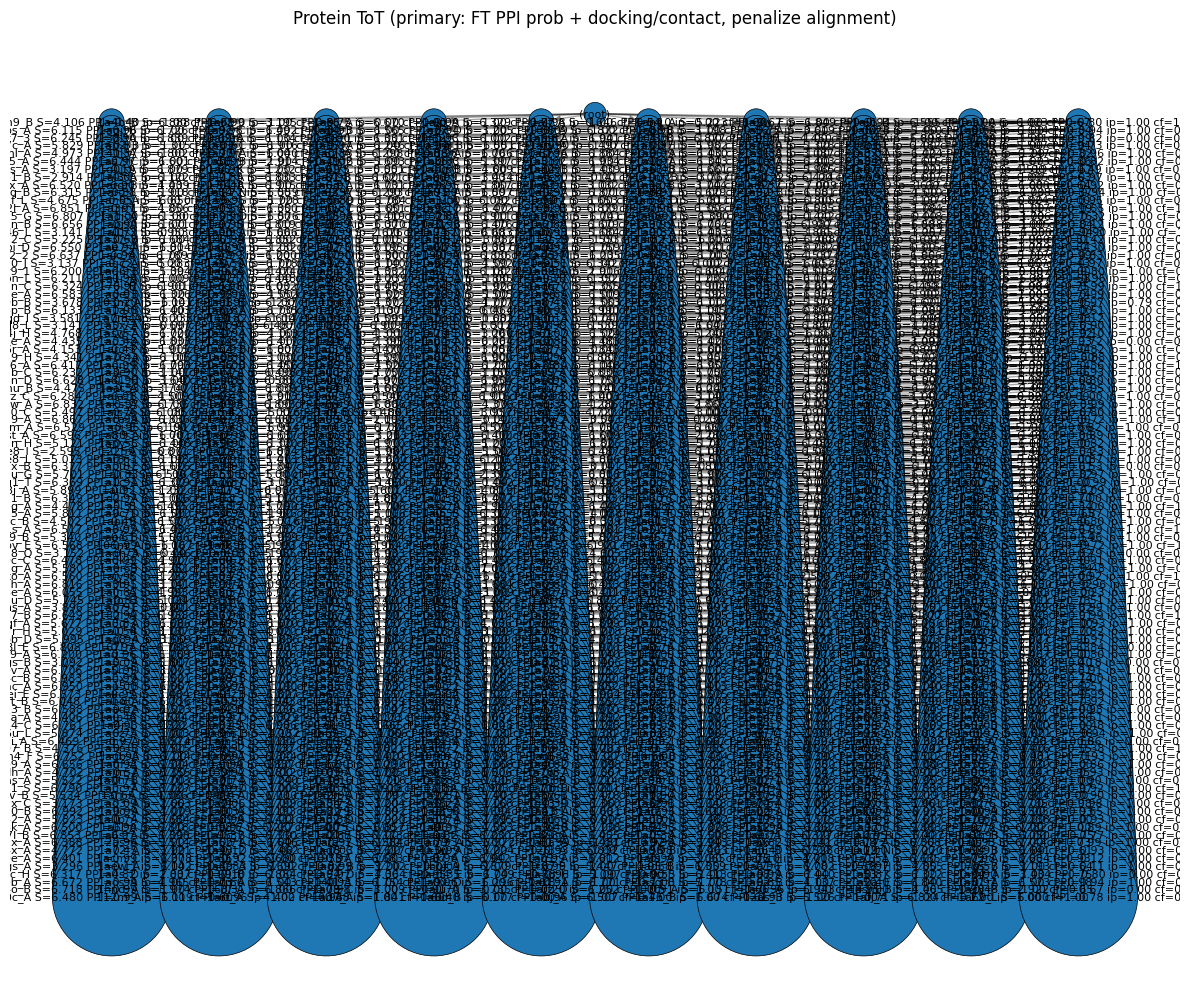

In [33]:
# ============================================================
# Protein ToT search using cached ESM2 embeddings + ipTM-like docking
# UPDATED value function:
#   - Primary: baseline_mlp_combined_ft.pt interaction probability (PPI_FT)
#   - Adds: ipTM-like docking proxy
#   - Adds: inter-chain contact fraction score (CONTACT_FRAC)
#   - Adds: structural similarity penalty (ALIGN_RMSD) to avoid "dock by alignment"
#   - Adds: stoichiometry/size-compatibility score from chain lengths (STOICH)
#
# Notes:
#   - Uses cached chain embeddings (ESM2 mean-pooled) for BOTH cosine + PPI_FT.
#   - If receptor/ligand embedding missing from cache, computes on-the-fly via Transformers ESM2.
#   - Docking is still a cheap random rigid-body search on CA atoms.
# ============================================================

!pip install transformers torch tqdm networkx matplotlib requests py3Dmol numpy

import os, re, math, random, gc, hashlib, textwrap
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import requests
import py3Dmol
from transformers import AutoTokenizer, AutoModel

# ===========================
# CONFIG
# ===========================
PDB_SEQRES_PATH   = "pdb_seqres.txt"
ESM_EMB_PATH      = "esm2_chain_embeddings_random3000.pt"

RECEPTOR_ID       = "101m_A"
MAX_LIGANDS_TOT   = 2000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEFAULT_SEED = 13

# docking guards
MIN_CA_LIG  = 40
MIN_CA_REC  = 40

# fine-tuned PPI model checkpoint (your request)
FT_CKPT = "string_data/baseline_mlp_combined_ft.pt"

PDB_TEXT_CACHE: Dict[str, str] = {}
CA_CACHE: Dict[str, np.ndarray] = {}
DOCK_CACHE: Dict[Tuple[str, str], Tuple[float, np.ndarray, np.ndarray]] = {}
POSE_CACHE: Dict[Tuple[str, str], Tuple[np.ndarray, np.ndarray, np.ndarray]] = {}  # (R_best, t_best, lig_best)

# ===========================
# SEEDING
# ===========================
def set_seed(seed: Optional[int]):
    if seed is None:
        return
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ===========================
# LOAD CACHED EMBEDDINGS
# ===========================
if not os.path.isfile(ESM_EMB_PATH):
    raise FileNotFoundError(f"{ESM_EMB_PATH} not found. Run the precompute script first.")

print(f"Loading cached embeddings from {ESM_EMB_PATH}...")
embfile = torch.load(ESM_EMB_PATH, map_location="cpu")
CHAIN_EMB: Dict[str, torch.Tensor] = embfile["embeddings"]
ESM_MODEL_NAME: str = embfile.get("model_name", "facebook/esm2_t12_35M_UR50D")
print(f"Loaded {len(CHAIN_EMB)} chain embeddings from model {ESM_MODEL_NAME}")

EMB_DIM = next(iter(CHAIN_EMB.values())).numel()
print("Embedding dim:", EMB_DIM)

# ===========================
# PARSE pdb_seqres.txt
# ===========================
def parse_pdb_seqres(path: str) -> Dict[str, dict]:
    records: Dict[str, dict] = {}
    header_re = re.compile(r"^(\S+)\s+mol:(\S+)\s+length:(\d+)\s*(.*)$")

    cid: Optional[str] = None
    mol = ""
    ln = 0
    desc = ""
    seq_lines: List[str] = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if cid is not None and seq_lines:
                    records[cid] = {"mol": mol.lower(), "len": ln, "desc": desc, "seq": "".join(seq_lines)}
                m = header_re.match(line[1:])
                if m:
                    cid, mol, ln_str, desc = m.groups()
                    ln = int(ln_str)
                    seq_lines = []
                else:
                    cid = line[1:].split()[0]
                    mol = "unknown"
                    ln = 0
                    desc = ""
                    seq_lines = []
            else:
                seq_lines.append(line)

    if cid is not None and seq_lines:
        records[cid] = {"mol": mol.lower(), "len": ln, "desc": desc, "seq": "".join(seq_lines)}
    return records

if not os.path.isfile(PDB_SEQRES_PATH):
    raise FileNotFoundError(f"{PDB_SEQRES_PATH} not found in current directory")

print(f"Parsing {PDB_SEQRES_PATH}...")
records = parse_pdb_seqres(PDB_SEQRES_PATH)
print(f"Found {len(records)} chains total.")

if RECEPTOR_ID not in records:
    raise ValueError(f"Receptor chain {RECEPTOR_ID} not found in pdb_seqres.txt")

# ===========================
# BASIC SEQUENCE UTILS
# ===========================
AA20      = set("ACDEFGHIKLMNPQRSTVWY")
HYDRO     = set("AVILMFYW")
POLAR     = set("STNQCH")
POSITIVE  = set("KRH")
NEGATIVE  = set("DE")

def clean_protein(seq: str) -> str:
    return "".join(c for c in seq.upper() if c in AA20)

def pair_score(a: str, b: str) -> float:
    a = a.upper(); b = b.upper()
    if (a in POSITIVE and b in NEGATIVE) or (a in NEGATIVE and b in POSITIVE): return 2.0
    if a in HYDRO and b in HYDRO: return 1.0
    if a in POLAR and b in POLAR: return 0.5
    if (a in POSITIVE and b in POSITIVE) or (a in NEGATIVE and b in NEGATIVE): return -1.0
    return -0.2

def binding_score(rec_seq: str, lig_seq: str) -> float:
    R = clean_protein(rec_seq)
    L = clean_protein(lig_seq)
    if not R or not L: return -1e9
    if len(L) > len(R): R, L = L, R
    Lr, Ll = len(R), len(L)
    best = -1e9
    for shift in range(-Ll + 1, Lr):
        sr = max(0, shift)
        sl = max(0, -shift)
        overlap = min(Lr - sr, Ll - sl)
        if overlap <= 0: continue
        s = 0.0
        for k in range(overlap):
            s += pair_score(R[sr + k], L[sl + k])
        s_norm = s / overlap
        len_ratio = overlap / max(Lr, Ll)
        s_norm *= (0.5 + 0.5 * len_ratio)
        best = max(best, s_norm)
    return best

def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a / (a.norm(p=2) + 1e-8)
    b = b / (b.norm(p=2) + 1e-8)
    return float(torch.dot(a, b).item())

def clamp01(x: float) -> float:
    return max(0.0, min(1.0, float(x)))

# ===========================
# On-the-fly ESM embedding (ONLY if missing from CHAIN_EMB)
# (kept light: encoder only, mean over tokens)
# ===========================
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loading ESM encoder ({ESM_MODEL_NAME}) on {DEVICE} (for fallback embeddings)...")
esm_tok = AutoTokenizer.from_pretrained(ESM_MODEL_NAME)
esm_mdl_enc = AutoModel.from_pretrained(ESM_MODEL_NAME).to(DEVICE).eval()

@torch.no_grad()
def esm_embed_fallback(seq: str, max_len: int = 1022) -> torch.Tensor:
    seq = clean_protein(seq)
    if len(seq) == 0:
        return torch.zeros(EMB_DIM, device=DEVICE)
    seq = seq[:max_len]
    enc = esm_tok(seq, return_tensors="pt", add_special_tokens=True, truncation=True, max_length=max_len + 2)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    out = esm_mdl_enc(**enc)
    # mean pool over tokens (good enough for fallback)
    emb = out.last_hidden_state.mean(dim=1)[0]
    if emb.numel() != EMB_DIM:
        # if mismatch, project by trunc/pad
        if emb.numel() > EMB_DIM:
            emb = emb[:EMB_DIM]
        else:
            emb = torch.cat([emb, torch.zeros(EMB_DIM - emb.numel(), device=DEVICE)], dim=0)
    return emb

def get_chain_emb(chain_id: str) -> torch.Tensor:
    if chain_id in CHAIN_EMB:
        return CHAIN_EMB[chain_id].to(DEVICE)
    # fallback from seqres
    if chain_id not in records:
        return torch.zeros(EMB_DIM, device=DEVICE)
    return esm_embed_fallback(records[chain_id]["seq"])

# ===========================
# PPI MODEL (Baseline MLP) + fine-tuned weights
# ===========================
class BaselineMLP(nn.Module):
    def __init__(self, embedding_dim: int, hidden_dims=[512, 256, 128], dropout=0.3):
        super().__init__()
        layers = []
        in_dim = embedding_dim * 2
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout), nn.BatchNorm1d(h)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, emb1, emb2):
        x = torch.cat([emb1, emb2], dim=1)
        logits = self.net(x).squeeze(-1)
        return torch.sigmoid(logits)

ppi_model = BaselineMLP(embedding_dim=EMB_DIM).to(DEVICE).eval()
if not os.path.exists(FT_CKPT):
    raise FileNotFoundError(f"Missing fine-tuned checkpoint: {FT_CKPT}")
ppi_model.load_state_dict(torch.load(FT_CKPT, map_location=DEVICE))
ppi_model.eval()
print("Loaded fine-tuned PPI model:", FT_CKPT)

@torch.no_grad()
def ppi_ft_prob(rec_emb: torch.Tensor, lig_emb: torch.Tensor) -> float:
    e1 = rec_emb.unsqueeze(0)
    e2 = lig_emb.unsqueeze(0)
    p = ppi_model(e1, e2).item()
    return float(p)

# ===========================
# TREE BOOK
# ===========================
class TreeBook:
    def __init__(self):
        self.G = nx.DiGraph()
        self.next_id = 0
        self.attrs: Dict[int, Dict[str, object]] = {}
        self.info: Dict[int, Tuple[str, ...]] = {}

    def add_node(self, depth: int, label: str, info: Tuple[str, ...]) -> int:
        nid = self.next_id
        self.next_id += 1
        self.G.add_node(nid)
        self.attrs[nid] = {"depth": depth, "label": label}
        self.info[nid] = info
        return nid

    def add_edge(self, u: int, v: int):
        self.G.add_edge(u, v)

def _layered_tb(G, attrs):
    levels: Dict[int, List[int]] = {}
    for n in G.nodes():
        d = attrs[n]["depth"]
        levels.setdefault(d, []).append(n)
    pos = {}
    y_gap = 1.8
    x_gap = 1.6
    for d in sorted(levels.keys()):
        row = sorted(levels[d])
        width = (len(row) - 1) * x_gap
        for i, nid in enumerate(row):
            pos[nid] = (-width / 2 + i * x_gap, -d * y_gap)
    return pos

def plot_tree(tb: TreeBook, title="Protein ToT (Top→Bottom)"):
    if tb.G.number_of_nodes() == 0:
        print("[viz] Empty tree.")
        return
    pos = _layered_tb(tb.G, tb.attrs)
    colors, sizes, labels = [], [], {}
    for nid in tb.G.nodes():
        colors.append("#1f77b4")
        d = tb.attrs[nid]["depth"]
        sizes.append(260 + 70 * d)
        lbl = tb.attrs[nid]["label"] or "(root)"
        labels[nid] = (lbl[:42] + "…") if len(lbl) > 43 else lbl
    plt.figure(figsize=(12, 10))
    nx.draw_networkx_edges(tb.G, pos, alpha=0.35, arrows=True, arrowstyle="-|>", min_target_margin=8)
    nx.draw_networkx_nodes(tb.G, pos, node_color=colors, node_size=sizes, linewidths=0.5, edgecolors="k")
    nx.draw_networkx_labels(tb.G, pos, labels=labels, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ===========================
# PARAMS + NODE
# ===========================
@dataclass
class P:
    max_depth: int = 5
    max_nodes: int = 1000
    branch: int = 10

    # value weights (PPI_FT is the main term)
    w_ppi: float = 4.0      # <-- primary term (fine-tuned baseline MLP)
    w_iptm: float = 1.5     # docking proxy
    w_contact: float = 0.8  # contact fraction (anti-alignment heuristic)
    w_esm: float = 0.2      # cosine on embeddings
    w_bind: float = 0.05    # crude seq alignment heuristic
    w_dock: float = 0.1     # raw docking score (normalized)
    w_stoich: float = 0.3   # size/stoichiometry compatibility
    w_align_pen: float = 0.8  # penalty for too-good structural alignment (avoid "similar fold docking")

    depth_penalty: float = 0.02

@dataclass
class Node:
    nid: int
    info: Tuple[str, ...]
    depth: int
    value: float
    parent: float

# ===========================
# PDB / GEOMETRY
# ===========================
def fetch_pdb_text(pdb_id: str) -> str:
    pdb_id = pdb_id.upper()
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    resp = requests.get(url, timeout=30)
    if resp.status_code != 200 or not resp.text.strip():
        return ""
    return resp.text

def split_pdb_chain(id_str: str):
    parts = id_str.split("_", 1)
    pdb_id = parts[0]
    chain = parts[1].strip().upper() if len(parts) == 2 and parts[1] else None
    return pdb_id, chain

def parse_pdb_atoms(pdb_txt: str, chain_id: str = None):
    atoms = []
    if not pdb_txt:
        return atoms
    saw_model = False
    in_first_model = False
    chain_id_norm = chain_id.upper() if chain_id is not None else None

    for line in pdb_txt.splitlines():
        if line.startswith("MODEL"):
            if not saw_model:
                saw_model = True
                in_first_model = True
            else:
                break
            continue
        if line.startswith("ENDMDL") and in_first_model:
            break
        if not (line.startswith("ATOM") or line.startswith("HETATM")):
            continue
        if chain_id_norm is not None and line[21].upper().strip() != chain_id_norm:
            continue
        alt = line[16].strip()
        if alt not in ("", "A"):
            continue
        try:
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
        except ValueError:
            continue
        atoms.append({"line": line, "x": x, "y": y, "z": z})
    return atoms

def get_ca_coords(atoms):
    coords = []
    for a in atoms:
        if a["line"][12:16].strip() == "CA":
            coords.append([a["x"], a["y"], a["z"]])
    return np.array(coords, dtype=np.float64) if coords else np.zeros((0, 3))

def get_pdb_text_cached(pdb_id: str) -> str:
    pdb_id = pdb_id.upper()
    if pdb_id in PDB_TEXT_CACHE:
        return PDB_TEXT_CACHE[pdb_id]
    txt = fetch_pdb_text(pdb_id)
    PDB_TEXT_CACHE[pdb_id] = txt
    return txt

def get_ca_for_chain(chain_id: str) -> np.ndarray:
    if chain_id in CA_CACHE:
        return CA_CACHE[chain_id]
    pdb_id, ch = split_pdb_chain(chain_id)
    pdb_txt = get_pdb_text_cached(pdb_id)
    if not pdb_txt:
        CA_CACHE[chain_id] = np.zeros((0, 3))
        return CA_CACHE[chain_id]
    atoms = parse_pdb_atoms(pdb_txt, chain_id=ch)
    ca = get_ca_coords(atoms)
    CA_CACHE[chain_id] = ca
    return ca

# ===========================
# DOCKING + ipTM-like + CONTACT + ALIGNMENT PENALTY
# ===========================
def random_rotation_matrix() -> np.ndarray:
    u1, u2, u3 = np.random.rand(3)
    q1 = math.sqrt(1-u1) * math.sin(2*math.pi*u2)
    q2 = math.sqrt(1-u1) * math.cos(2*math.pi*u2)
    q3 = math.sqrt(u1)   * math.sin(2*math.pi*u3)
    q4 = math.sqrt(u1)   * math.cos(2*math.pi*u3)
    x, y, z, w = q1, q2, q3, q4
    return np.array([
        [1-2*(y*y+z*z),   2*(x*y - z*w),   2*(x*z + y*w)],
        [2*(x*y + z*w),   1-2*(x*x+z*z),   2*(y*z - x*w)],
        [2*(x*z - y*w),   2*(y*z + x*w),   1-2*(x*x+y*y)]
    ], dtype=float)

def interface_score(rec_ca: np.ndarray, lig_ca: np.ndarray, contact_cut: float = 6.0, clash_cut: float = 2.0):
    if rec_ca.size == 0 or lig_ca.size == 0:
        return -1e9
    diff = rec_ca[:, None, :] - lig_ca[None, :, :]
    dist2 = np.sum(diff * diff, axis=-1)
    contacts = dist2 < contact_cut**2
    clashes  = dist2 < clash_cut**2
    return float(contacts.sum() - 10 * clashes.sum())

def search_best_docking_pose(rec_ca: np.ndarray, lig_ca: np.ndarray, n_poses: int = 60, trans_std: float = 6.0):
    if rec_ca.size == 0 or lig_ca.size == 0:
        return -1e9, np.eye(3), np.zeros(3), lig_ca
    rec_center = rec_ca.mean(axis=0)
    lig_center0 = lig_ca.mean(axis=0)

    best = -1e9
    best_R = np.eye(3)
    best_t = np.zeros(3)
    best_lig = lig_ca

    for _ in range(n_poses):
        R = random_rotation_matrix()
        delta = np.random.normal(scale=trans_std, size=3)
        t = rec_center + delta - R @ lig_center0
        lig_try = (R @ lig_ca.T).T + t
        s = interface_score(rec_ca, lig_try)
        if s > best:
            best = s
            best_R = R
            best_t = t
            best_lig = lig_try
    return float(best), best_R, best_t, best_lig

def docking_pose_cached(rec_chain_id: str, lig_chain_id: str, n_poses: int = 60, trans_std: float = 6.0):
    key = (rec_chain_id, lig_chain_id)
    if key in POSE_CACHE:
        return POSE_CACHE[key]
    rec_ca = get_ca_for_chain(rec_chain_id)
    lig_ca = get_ca_for_chain(lig_chain_id)
    if rec_ca.shape[0] < MIN_CA_REC or lig_ca.shape[0] < MIN_CA_LIG:
        POSE_CACHE[key] = (np.eye(3), np.zeros(3), lig_ca)
        return POSE_CACHE[key]
    _, R_best, t_best, lig_best = search_best_docking_pose(rec_ca, lig_ca, n_poses=n_poses, trans_std=trans_std)
    POSE_CACHE[key] = (R_best, t_best, lig_best)
    return POSE_CACHE[key]

def docking_score_cached(rec_chain_id: str, lig_chain_id: str, n_poses: int = 60, trans_std: float = 6.0) -> float:
    key = (rec_chain_id, lig_chain_id)
    if key in DOCK_CACHE:
        return DOCK_CACHE[key][0]

    rec_ca = get_ca_for_chain(rec_chain_id)
    lig_ca = get_ca_for_chain(lig_chain_id)
    if rec_ca.shape[0] < MIN_CA_REC or lig_ca.shape[0] < MIN_CA_LIG:
        DOCK_CACHE[key] = (0.0, np.eye(3), np.zeros(3))
        return 0.0

    raw, R_best, t_best, _ = search_best_docking_pose(rec_ca, lig_ca, n_poses=n_poses, trans_std=trans_std)
    denom = max(1.0, math.sqrt(len(rec_ca) * len(lig_ca)))
    norm = raw / denom
    DOCK_CACHE[key] = (float(norm), R_best, t_best)
    return float(norm)

def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

def iptm_like_score(rec_chain_id: str, lig_chain_id: str, contact_cut: float = 8.0, n_poses: int = 80, trans_std: float = 6.0) -> float:
    rec_ca = get_ca_for_chain(rec_chain_id)
    lig_ca = get_ca_for_chain(lig_chain_id)
    if rec_ca.shape[0] < MIN_CA_REC or lig_ca.shape[0] < MIN_CA_LIG:
        return 0.0
    _, _, lig_best = docking_pose_cached(rec_chain_id, lig_chain_id, n_poses=n_poses, trans_std=trans_std)
    diff = rec_ca[:, None, :] - lig_best[None, :, :]
    dist = np.sqrt(np.sum(diff * diff, axis=-1) + 1e-12)
    mask = dist < contact_cut
    if not np.any(mask):
        return 0.0
    dists = dist[mask]
    w = np.clip((contact_cut - dists) / (contact_cut - 2.0 + 1e-8), 0.0, 1.0)
    contact_strength = float(w.sum())
    size_norm = math.sqrt(len(rec_ca) * len(lig_ca))
    s = contact_strength / max(1.0, size_norm)
    return float(sigmoid(10.0 * (s - 0.05)))

def contact_fraction_score(rec_chain_id: str, lig_chain_id: str, contact_cut: float = 8.0, n_poses: int = 80, trans_std: float = 6.0) -> float:
    """Fraction of ligand CA atoms that have >=1 receptor CA within contact_cut (after best docking pose)."""
    rec_ca = get_ca_for_chain(rec_chain_id)
    lig_ca = get_ca_for_chain(lig_chain_id)
    if rec_ca.shape[0] < MIN_CA_REC or lig_ca.shape[0] < MIN_CA_LIG:
        return 0.0
    _, _, lig_best = docking_pose_cached(rec_chain_id, lig_chain_id, n_poses=n_poses, trans_std=trans_std)
    diff = rec_ca[:, None, :] - lig_best[None, :, :]
    dist2 = np.sum(diff * diff, axis=-1)
    close = dist2 < (contact_cut ** 2)
    lig_has_contact = close.any(axis=0)  # per ligand atom
    frac = float(lig_has_contact.mean()) if lig_has_contact.size else 0.0
    return clamp01(frac)

def kabsch_rmsd(A: np.ndarray, B: np.ndarray) -> float:
    """RMSD after optimal rotation (Kabsch). A,B: [n,3]"""
    if A.shape[0] == 0 or B.shape[0] == 0:
        return 1e9
    n = min(A.shape[0], B.shape[0])
    A = A[:n].astype(np.float64)
    B = B[:n].astype(np.float64)
    Ac = A - A.mean(axis=0, keepdims=True)
    Bc = B - B.mean(axis=0, keepdims=True)
    H = Ac.T @ Bc
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    Arot = Ac @ R
    diff = Arot - Bc
    return float(np.sqrt((diff * diff).sum() / n))

def alignment_penalty(rec_chain_id: str, lig_chain_id: str) -> float:
    """
    Penalize if ligand aligns *too well* to receptor (structural similarity),
    which can lead to misleading "docking by fold alignment".
    Returns penalty in [0,1], higher = worse.
    """
    rec_ca = get_ca_for_chain(rec_chain_id)
    lig_ca = get_ca_for_chain(lig_chain_id)
    if rec_ca.shape[0] < MIN_CA_REC or lig_ca.shape[0] < MIN_CA_LIG:
        return 0.0
    rmsd = kabsch_rmsd(rec_ca, lig_ca)  # crude (no sequence matching)
    # if rmsd < ~3Å, treat as "too similar" and penalize strongly
    # map rmsd to penalty: rmsd=2 -> ~0.88, rmsd=4 -> ~0.27, rmsd=6 -> ~0.07
    pen = float(sigmoid(-(rmsd - 3.0)))  # decreasing with rmsd
    return clamp01(pen)

# ===========================
# Stoichiometry / size compatibility
# ===========================
def stoich_score(rec_id: str, lig_id: str) -> float:
    """
    Cheap size-compatibility: prefer ligand lengths not wildly mismatched.
    Returns in [0,1]. 1.0 when lengths similar; decays with log ratio.
    """
    lr = float(max(1, records[rec_id].get("len", len(records[rec_id]["seq"]))))
    ll = float(max(1, records[lig_id].get("len", len(records[lig_id]["seq"]))))
    r = ll / lr
    s = math.exp(-abs(math.log(r)))  # r=1 -> 1.0, r=0.5 or 2 -> ~0.5
    return clamp01(s)

# ===========================
# ToT
# ===========================
class ProteinToT:
    def __init__(self, receptor_id: str, records: Dict[str, dict], lig_ids: List[str], p: P):
        self.receptor_id = receptor_id
        self.records = records
        self.lig_ids = lig_ids
        self.rec_seq = records[receptor_id]["seq"]

        self.rec_emb = get_chain_emb(receptor_id)
        self.p = p

        self.tb = TreeBook()
        self.nodes_evaluated = 0
        self.visited_ligs = set()
        self.best_lig = None
        self.best_score = -1e9
        self.best_parts = None

    def _canon(self, infos: List[str]) -> Tuple[str, ...]:
        out, seen = [], set()
        for s in infos:
            t = s.strip()
            k = t.lower()
            if t and k not in seen:
                seen.add(k)
                out.append(t[:240])
        return tuple(sorted(out))

    def _score_ligand(self, lig_id: str) -> Tuple[float, Dict[str, float]]:
        lig_seq = self.records[lig_id]["seq"]
        lig_emb = get_chain_emb(lig_id)

        # MAIN: fine-tuned PPI probability
        ppi_p = ppi_ft_prob(self.rec_emb, lig_emb)

        # docking features
        ip = iptm_like_score(self.receptor_id, lig_id)
        cf = contact_fraction_score(self.receptor_id, lig_id)
        dock = docking_score_cached(self.receptor_id, lig_id)

        # anti-alignment penalty
        apen = alignment_penalty(self.receptor_id, lig_id)

        # aux similarity
        cos = cosine_sim(self.rec_emb, lig_emb)
        bind = binding_score(self.rec_seq, lig_seq)

        # stoichiometry/size compatibility
        st = stoich_score(self.receptor_id, lig_id)

        score = (
            self.p.w_ppi     * ppi_p +
            self.p.w_iptm    * ip +
            self.p.w_contact * cf +
            self.p.w_esm     * cos +
            self.p.w_bind    * bind +
            self.p.w_dock    * dock +
            self.p.w_stoich  * st -
            self.p.w_align_pen * apen
        )

        parts = {
            "PPI_FT": ppi_p,
            "ipTM_like": ip,
            "CONTACT_FRAC": cf,
            "ALIGN_PEN": apen,
            "ESM_cos": cos,
            "bind": bind,
            "dock": dock,
            "stoich": st,
        }
        return float(score), parts

    def _value(self, score: float, depth: int) -> float:
        return score - self.p.depth_penalty * depth

    def _expand(self, node: Node):
        remaining = [cid for cid in self.lig_ids if cid not in self.visited_ligs]
        if not remaining:
            return []
        random.shuffle(remaining)
        kids = []
        for lig_id in remaining[: self.p.branch]:
            score, parts = self._score_ligand(lig_id)
            val = self._value(score, node.depth + 1)
            info = self._canon(list(node.info) + [
                f"LIG={lig_id}",
                f"SCORE={score:.4f}",
                f"PPI_FT={parts['PPI_FT']:.4f}",
                f"ipTM_like={parts['ipTM_like']:.4f}",
                f"CONTACT_FRAC={parts['CONTACT_FRAC']:.4f}",
                f"ALIGN_PEN={parts['ALIGN_PEN']:.4f}",
                f"stoich={parts['stoich']:.4f}",
            ])
            kids.append((val, lig_id, info, score, parts))
        return kids

    def solve(self, seed: Optional[int] = DEFAULT_SEED):
        set_seed(seed)

        root_info = self._canon([f"RECEPTOR={self.receptor_id}"])
        root_nid = self.tb.add_node(depth=0, label="(root)", info=root_info)
        self.tb.attrs[root_nid]["value"] = 0.0
        root = Node(nid=root_nid, info=root_info, depth=0, value=0.0, parent=-1e9)

        stack = [root]

        print(f"Starting Protein ToT search over {len(self.lig_ids)} ligands (max_nodes={self.p.max_nodes}, branch={self.p.branch})")
        with tqdm(total=self.p.max_nodes, desc="Nodes", unit="node",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{rate_fmt}]") as pbar:
            while stack and self.nodes_evaluated < self.p.max_nodes:
                node = stack.pop()
                children = self._expand(node)
                if not children:
                    continue

                for val, lig_id, info, score, parts in children:
                    if self.nodes_evaluated >= self.p.max_nodes:
                        break

                    self.visited_ligs.add(lig_id)
                    if score > self.best_score:
                        self.best_score = score
                        self.best_lig = lig_id
                        self.best_parts = parts

                    label = f"{lig_id} S={score:.3f} PPI={parts['PPI_FT']:.2f} ip={parts['ipTM_like']:.2f} cf={parts['CONTACT_FRAC']:.2f}"
                    child_nid = self.tb.add_node(depth=node.depth + 1, label=label, info=info)
                    self.tb.attrs[child_nid]["value"] = val
                    self.tb.add_edge(node.nid, child_nid)

                    stack.append(Node(nid=child_nid, info=info, depth=node.depth + 1, value=val, parent=node.value))

                    self.nodes_evaluated += 1
                    pbar.update(1)

        return {"best_ligand": self.best_lig, "best_score": self.best_score, "best_parts": self.best_parts,
                "tree": self.tb, "nodes": self.nodes_evaluated}

# ===========================
# MAIN
# ===========================
if __name__ == "__main__":
    # ligand pool: protein chains with cached embeddings (fast start), but we allow fallback too
    ligands = [cid for cid, rec in records.items() if cid != RECEPTOR_ID and rec["mol"] == "protein"]
    # prefer those with cached embeddings first
    ligands = sorted(ligands, key=lambda x: (x not in CHAIN_EMB, x))
    ligands = ligands[:MAX_LIGANDS_TOT]

    if not ligands:
        raise RuntimeError("No protein ligands found in pdb_seqres records.")

    params = P(
        max_depth=5, max_nodes=1000, branch=10,
        w_ppi=4.0, w_iptm=1.5, w_contact=0.8, w_esm=0.2, w_bind=0.05, w_dock=0.1,
        w_stoich=0.3, w_align_pen=0.8,
        depth_penalty=0.02
    )

    solver = ProteinToT(RECEPTOR_ID, records, ligands, params)
    res = solver.solve(seed=DEFAULT_SEED)

    best_lig = res["best_ligand"]
    print("\n=== BEST LIGAND ===")
    print("Receptor:", RECEPTOR_ID)
    print("Ligand  :", best_lig)
    print("Score   :", f"{res['best_score']:.3f}")

    if best_lig is not None:
        parts = res["best_parts"] or {}
        print("\n--- Decomposed (best) ---")
        for k in ["PPI_FT","ipTM_like","CONTACT_FRAC","ALIGN_PEN","stoich","ESM_cos","bind","dock"]:
            if k in parts:
                print(f"{k:>12s}: {parts[k]:.4f}")

        ca_l = get_ca_for_chain(best_lig).shape[0]
        ca_r = get_ca_for_chain(RECEPTOR_ID).shape[0]
        print("\nCA atoms: receptor =", ca_r, "| ligand =", ca_l)

    print("\nNodes evaluated:", res["nodes"])
    print("\nPlotting search tree...")
    plot_tree(res["tree"], title="Protein ToT (primary: FT PPI prob + docking/contact, penalize alignment)")


# Visualization and Docking

In [45]:
def dock_and_show(receptor_id, ligand_id,
                  n_poses=80,
                  width=900, height=700,
                  spin=True):

    rec_pdb, rec_chain = receptor_id.split("_")
    lig_pdb, lig_chain = ligand_id.split("_")

    rec_txt = fetch_pdb(rec_pdb)
    lig_txt = fetch_pdb(lig_pdb)

    rec_atoms = parse_atoms(rec_txt, rec_chain)
    lig_atoms = parse_atoms(lig_txt, lig_chain)

    rec_ca = get_ca_coords(rec_atoms)
    lig_ca = get_ca_coords(lig_atoms)

    if len(rec_ca) < 30 or len(lig_ca) < 30:
        raise RuntimeError("Too few CA atoms for docking")

    # ---- Docking (same as ToT logic)
    lig_best = dock_best_pose(rec_ca, lig_ca, n_poses=n_poses)

    # Recover rigid transform
    lc0 = lig_ca.mean(axis=0)
    lc1 = lig_best.mean(axis=0)
    X = lig_ca - lc0
    Y = lig_best - lc1
    U, _, Vt = np.linalg.svd(X.T @ Y)
    R = Vt.T @ U.T
    t = lc1 - R @ lc0

    lig_docked_pdb = apply_transform(lig_atoms, R, t)

    # ---- Visualization
    view = py3Dmol.view(width=900, height=700)

    # receptor
    view.addModel(rec_txt, "pdb")
    view.setStyle(
        {"model": 0, "chain": rec_chain},
        {"cartoon": {"color": "steelblue"}}
    )

    # ligand (docked)
    view.addModel(lig_docked_pdb, "pdb")
    view.setStyle(
        {"model": 1, "chain": lig_chain},
        {"cartoon": {"color": "tomato"}}
    )

    # show interface residues as sticks (both sides)
    view.addStyle(
        {"model": 0, "within": {"distance": 6.0, "model": 1}},
        {"stick": {"radius": 0.2, "color": "yellow"}}
    )
    view.addStyle(
        {"model": 1, "within": {"distance": 6.0, "model": 0}},
        {"stick": {"radius": 0.2, "color": "yellow"}}
    )

    # clean look
    view.setBackgroundColor("white")
    view.zoomTo()

    # rotate animation
    view.spin(True)

    return view



In [47]:
view = dock_and_show("101m_A", "1aku_A")
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.